In [6]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

addArchRThreads(16)
options(repr.plot.width=15, repr.plot.height=10)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==

In [7]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

library(scuttle)


Loading required package: SingleCellExperiment



In [8]:
matrix = 'GeneScoreMatrix'#'GeneScoreMatrix'
maxDist = 150000
TF_peak_corr_thr = 0.4

In [9]:
# Motif enrichment
#ArchRProject <- addMotifAnnotations(ArchRProj = ArchRProject, motifSet = "cisbp", name = "Motif", species='Homo sapiens', force=TRUE)

In [10]:
# get peak-motif matrix
matches = getMatches(ArchRProject)

colnames(matches) = sapply(strsplit(colnames(matches), '_'), '[', 1) # rename columns to actual TF names
colnames(matches@assays@data$matches) = sapply(strsplit(colnames(matches), '_'), '[', 1)

# get gene names
genes = getFeatures(ArchRProj = ArchRProject,
                    useMatrix = matrix)
# All TFs
TFs = sapply(strsplit(colnames(matches), '_'), '[', 1)

# TFs in our data
TFs = intersect(sapply(strsplit(genes, ':'), '[', 2), TFs)


In [11]:
length(TFs)

[1] 434

In [12]:

# get peaks
peaks = getPeakSet(ArchRProject)
peaks$idx = 1:length(peaks) # create unique peak IDs


In [13]:
# Get pseudobulk of genescore matrix

# get expressions
genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = matrix)

In [14]:
assayNames(genescores) <- "counts"

In [15]:
# pseudobulk by stage_clusters with statistic = mean
genescores_pseudobulk <- aggregateAcrossCells(genescores, id=genescores$stage_clusters, statistics = 'mean', BPPARAM = BPPARAM)

In [16]:
# extract matrix
genescores_pseudobulk.mtx = genescores_pseudobulk@assays@data$counts
rownames(genescores_pseudobulk.mtx) = rowData(genescores_pseudobulk)$name

In [17]:
# Get pseudobulk of peak accessibility matrix
#addArchRThreads(1)

peakacc = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")

In [18]:
assayNames(peakacc) <- "counts"
peakacc_pseudobulk <- aggregateAcrossCells(peakacc, id=peakacc$stage_clusters, statistics = 'mean', BPPARAM = BPPARAM)

In [19]:
# extract matrix
peakacc_pseudobulk.mtx = peakacc_pseudobulk@assays@data$counts
rownames(peakacc_pseudobulk.mtx) = 1:nrow(peakacc_pseudobulk.mtx)

In [22]:
peak.dt = as.data.table(peaks)

In [23]:
peak.dt

seqnames,start,end,width,strand,score,replicateScoreQuantile,groupScoreQuantile,Reproducibility,GroupReplicate,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,idx,N
<fct>,<int>,<int>,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>
chr1,131,631,501,*,65.43630,0.861,0.804,2,C5._.rabbit_BGRGP3,14806,WDR31,Distal,14806,ENSOCUT00000014253,0.5649,1,0
chr1,995,1495,501,*,118.18000,0.921,0.888,2,C5._.rabbit_BGRGP2,13942,WDR31,Distal,13942,ENSOCUT00000014253,0.5649,2,0
chr1,1710,2210,501,*,251.20800,0.975,0.963,2,C5._.rabbit_BGRGP2,13227,WDR31,Distal,13227,ENSOCUT00000014253,0.5848,3,0
chr1,2678,3178,501,*,44.10630,0.881,0.811,2,C12._.rabbit_BGRGP3,12259,WDR31,Distal,12259,ENSOCUT00000014253,0.7106,4,0
chr1,3276,3776,501,*,12.30850,0.466,0.212,2,C12._.rabbit_BGRGP2,11661,WDR31,Distal,11661,ENSOCUT00000014253,0.4810,5,0
chr1,4063,4563,501,*,16.59460,0.578,0.395,2,C5._.rabbit_BGRGP2,10874,WDR31,Distal,10874,ENSOCUT00000014253,0.5569,6,0
chr1,4724,5224,501,*,44.44580,0.804,0.721,2,C5._.rabbit_BGRGP2,10213,WDR31,Distal,10213,ENSOCUT00000014253,0.5808,7,0
chr1,5929,6429,501,*,12.00550,0.408,0.204,2,C9._.rabbit_BGRGP2,9008,WDR31,Distal,9008,ENSOCUT00000014253,0.5389,8,0
chr1,9535,10035,501,*,17.67120,0.604,0.435,2,C5._.rabbit_BGRGP3,5402,WDR31,Distal,5402,ENSOCUT00000014253,0.4132,9,0


In [20]:
peakacc_pseudobulk.mtx

,GD7_C1,GD7_C10,GD7_C11,GD7_C12,GD7_C13,GD7_C14,GD7_C15,GD7_C16,GD7_C17,GD7_C18,⋯,GD9_ExE_C11,GD9_ExE_C12,GD9_ExE_C2,GD9_ExE_C3,GD9_ExE_C4,GD9_ExE_C5,GD9_ExE_C6,GD9_ExE_C7,GD9_ExE_C8,GD9_ExE_C9
1,0.26086957,0.02337229,0.036220472,0.013266998,0.038961039,0.015037594,0.061674009,0.028616025,0.033018868,0.01245330,⋯,0.139423077,0.18,0.007326007,0.010,0.022346369,0.00000000,0.000000000,0.02083333,0.014814815,0.06
2,0.60869565,0.11185309,0.078740157,0.116086235,0.064935065,0.045112782,0.107929515,0.077523413,0.089622642,0.05354919,⋯,0.269230769,0.26,0.032967033,0.035,0.027932961,0.06666667,0.034782609,0.10416667,0.000000000,0.02
3,1.26086957,0.19031720,0.132283465,0.064676617,0.038961039,0.060150376,0.151982379,0.100416233,0.078616352,0.05728518,⋯,0.495192308,0.32,0.025641026,0.030,0.011173184,0.04444444,0.026086957,0.06250000,0.000000000,0.08
4,0.39130435,0.22036728,0.206299213,0.054726368,0.064935065,0.443609023,0.198237885,0.206555671,0.168238994,0.07347447,⋯,0.221153846,0.22,0.080586081,0.045,0.016759777,0.08888889,0.043478261,0.06250000,0.111111111,0.16
5,0.08695652,0.05175292,0.047244094,0.014925373,0.058441558,0.090225564,0.083700441,0.092091571,0.062893082,0.02490660,⋯,0.067307692,0.18,0.029304029,0.020,0.027932961,0.00000000,0.026086957,0.00000000,0.022222222,0.06
6,0.00000000,0.03505843,0.023622047,0.026533997,0.071428571,0.045112782,0.046255507,0.040582726,0.050314465,0.02366127,⋯,0.067307692,0.08,0.014652015,0.000,0.011173184,0.00000000,0.043478261,0.00000000,0.014814815,0.04
7,0.17391304,0.05008347,0.026771654,0.016583748,0.025974026,0.075187970,0.024229075,0.033818939,0.023584906,0.01369863,⋯,0.100961538,0.04,0.054945055,0.025,0.011173184,0.04444444,0.086956522,0.00000000,0.037037037,0.04
8,0.00000000,0.07846411,0.031496063,0.018242123,0.019480519,0.030075188,0.026431718,0.021331946,0.017295597,0.01867995,⋯,0.024038462,0.02,0.018315018,0.010,0.000000000,0.02222222,0.043478261,0.02083333,0.022222222,0.10
9,0.13043478,0.02170284,0.012598425,0.021558872,0.006493506,0.022556391,0.030837004,0.013527575,0.017295597,0.02117061,⋯,0.115384615,0.06,0.003663004,0.025,0.016759777,0.11111111,0.008695652,0.02083333,0.007407407,0.02
10,0.30434783,0.04006678,0.034645669,0.024875622,0.032467532,0.007518797,0.072687225,0.049947971,0.058176101,0.03486924,⋯,0.552884615,0.18,0.010989011,0.060,0.005586592,0.06666667,0.043478261,0.12500000,0.037037037,0.04


In [14]:
addArchRThreads(16)

# # Add peak to gene links
ArchRProject = addPeak2GeneLinks(
    ArchRProj = ArchRProject,
    reducedDims = "PeakMatrix",
    useMatrix = matrix,
    dimsToUse = 1:30,
    maxDist = maxDist) # The max distance should probably be greatly reduced

# Retrieve peak to gene links
peak_gene_links = getPeak2GeneLinks(ArchRProject, returnLoops = FALSE,
                                corCutOff = 0.45,
                                FDRCutOff = 1e-04, # test with more stringent values
                                varCutOffATAC = 0.25,
                                varCutOffRNA = 0.25,)

linked_genes = data.table(gene = sapply(strsplit(genes, ':'), '[', 2)[peak_gene_links$idxRNA],
                      idxRNA = peak_gene_links$idxRNA,
                      idxATAC = peak_gene_links$idxATAC,
                      peak_gene_corr = peak_gene_links$Correlation)


linked_peaks = as.data.table(peaks[unique(peak_gene_links$idxATAC),])



Setting default number of Parallel threads to 16.



In [15]:
library(parallel)

In [61]:
    TF_peak_ids = matches[matches@assays@data$matches[, 'TAL1']]@rowRanges$idx


In [62]:
summary(TF_peak_ids)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      1    3953    8518    9808   14269   31677 

In [68]:
nrow(matches)

[1] 332773

In [72]:
tail(matches@rowRanges)

GRanges object with 6 ranges and 13 metadata columns:
      seqnames              ranges strand |     score replicateScoreQuantile
         <Rle>           <IRanges>  <Rle> | <numeric>              <numeric>
   C9     chrX 111543279-111543779      * |  20.29650                  0.589
  C22     chrX 111629356-111629856      * |  10.42230                  0.438
  C16     chrX 111630125-111630625      * |  53.11070                  0.829
  C16     chrX 111631457-111631957      * |  11.49970                  0.414
  C15     chrX 111667102-111667602      * |  45.32670                  0.828
   C5     chrX 111678859-111679359      * |   8.75768                  0.319
      groupScoreQuantile Reproducibility      GroupReplicate distToGeneStart
               <numeric>       <numeric>         <character>       <integer>
   C9              0.436               3  C9._.rabbit_BGRGP2           10713
  C22              0.213               2 C22._.rabbit_BGRGP3             110
  C16              0.7

In [83]:
# Fix ArchRs weird idx of peaks per chr
matches@rowRanges$idx = 1:length(matches@rowRanges)

GetTFtargets = function(TF = 'TAL1', TF_peak_corr_thr=0.2){
    stopifnot(TF %in% TFs)
    print(TF)
    # get peaks that have TF motif
    TF_peak_ids = matches[matches@assays@data$matches[, TF]]@rowRanges$idx

    TF_peaks = linked_peaks[idx %in% TF_peak_ids,]

    # filter peaks that are correlate to expression of TF
    
    # get imputed TF expression
    TF_expr = genescores_pseudobulk.mtx[TF,]
    # TF_expr_imp = suppressMessages(imputeMatrix(mat = as.matrix(t(TF_expr)), 
    #                              imputeWeights = getImputeWeights(ArchRProject)))
    # get imputed peak accessibility
    peak_subset = peakacc_pseudobulk.mtx[TF_peaks$idx,]
    # peak_subset_imp = suppressMessages(imputeMatrix(mat = as.matrix(peak_subset), 
    #                              imputeWeights = getImputeWeights(ArchRProject)))

    # Get correlated peaks, very naive method
    # TF_peak_cor = apply(peak_subset, 1, function(x){cor(x, TF_expr)})
    # corr_peaks = names(TF_peak_cor[TF_peak_cor>TF_peak_corr_thr])
    TF_peak_cor = data.table(idxATAC = TF_peaks$idx, TF_peak_corr = as.vector(apply(peak_subset, 1, function(x){cor(x, TF_expr)})))
    TF_peak_cor = TF_peak_cor[abs(TF_peak_corr)>TF_peak_corr_thr, ]
    
    # Get network
    TF_peak_gene = merge(TF_peak_cor, linked_genes, by='idxATAC') %>% 
        .[,TF:=TF] %>%
        .[,c('TF','gene','idxATAC','idxRNA','TF_peak_corr','peak_gene_corr')]

    return(TF_peak_gene)
}

In [84]:
# get network
TF_targets = mclapply(TFs, GetTFtargets, 
            mc.cores=16) %>%
    rbindlist()

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


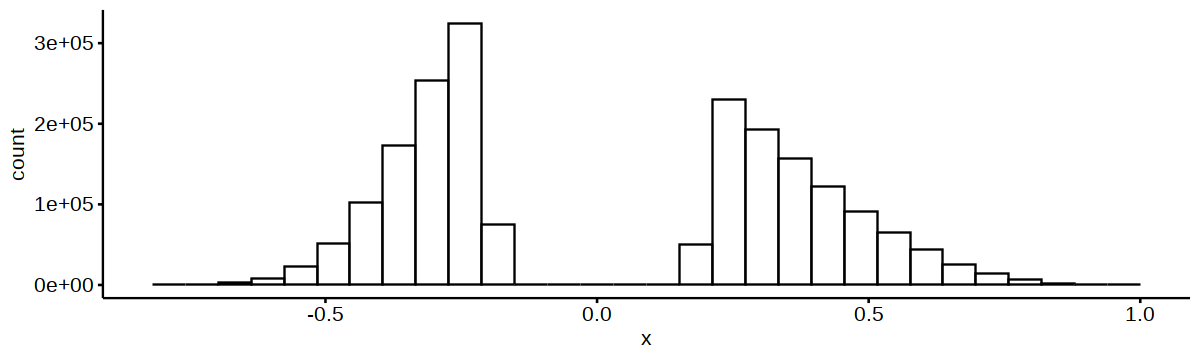

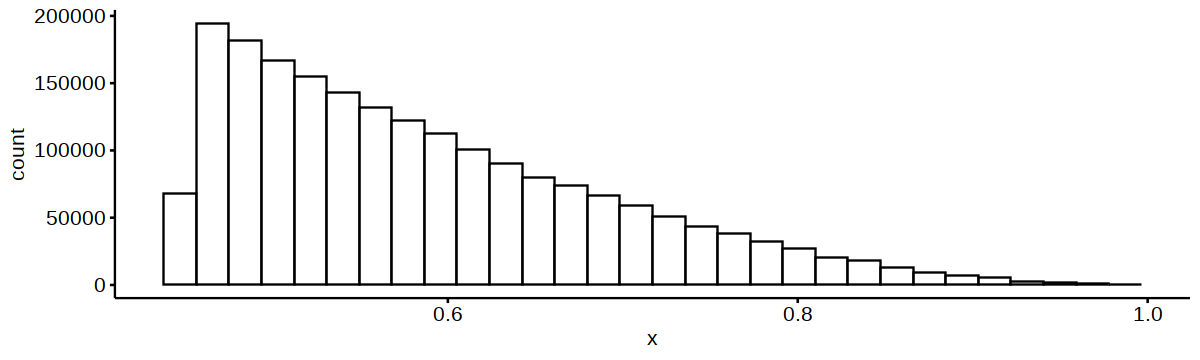

In [88]:
# define thresholds for correlation
options(repr.plot.width=10, repr.plot.height=3)
gghistogram(TF_targets$TF_peak_corr)
gghistogram(TF_targets$peak_gene_corr)

TF_targets_filt = TF_targets[abs(TF_peak_corr)>0.5 & peak_gene_corr>0.6]

In [89]:
rownames(genescores_pseudobulk) = rowData(genescores_pseudobulk)$name

In [113]:
head(TF_targets_filt[1000,])

TF,gene,idxATAC,idxRNA,TF_peak_corr,peak_gene_corr
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
WT1,ENSOCUG00000031260,4422,277,0.5600354,0.7533612


In [140]:
TF = 'WT1'
gene = 'WT1'

In [141]:
round(cor(as.vector(genescores_pseudobulk[TF,]@assays@data$counts), as.vector(genescores_pseudobulk[gene,]@assays@data$counts)),2)

[1] 1

In [142]:
head(TF_targets_filt)

TF,gene,idxATAC,idxRNA,TF_peak_corr,peak_gene_corr
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
TAL2,KAT14,87264,15486,0.5080747,0.8044678
TAL2,U6,109974,17036,0.5266985,0.7873630
TAL2,ENSOCUG00000001645,149665,19178,0.5124546,0.7539888
TAL2,NECTIN4,210376,4899,0.5272305,0.8372935
TAL2,TRDMT1,271476,8734,0.5518175,0.7556657
TAL2,CUBN,271476,8735,0.5518175,0.8300787


In [169]:
TF_gene = sapply(1:nrow(TF_targets_filt), function(x){
    cor(as.vector(genescores_pseudobulk[TF_targets_filt[x,]$TF,]@assays@data$counts),as.vector(genescores_pseudobulk[TF_targets_filt[x,]$gene,]@assays@data$counts))
})

In [182]:
TF_targets_filt = TF_targets[TF_peak_corr>0.5 & peak_gene_corr>0.75]
TF_targets_filt = TF_targets_filt[,TF_gene:=TF_gene]

In [184]:
TF_targets_filt = TF_targets_filt[TF_gene>0.3]

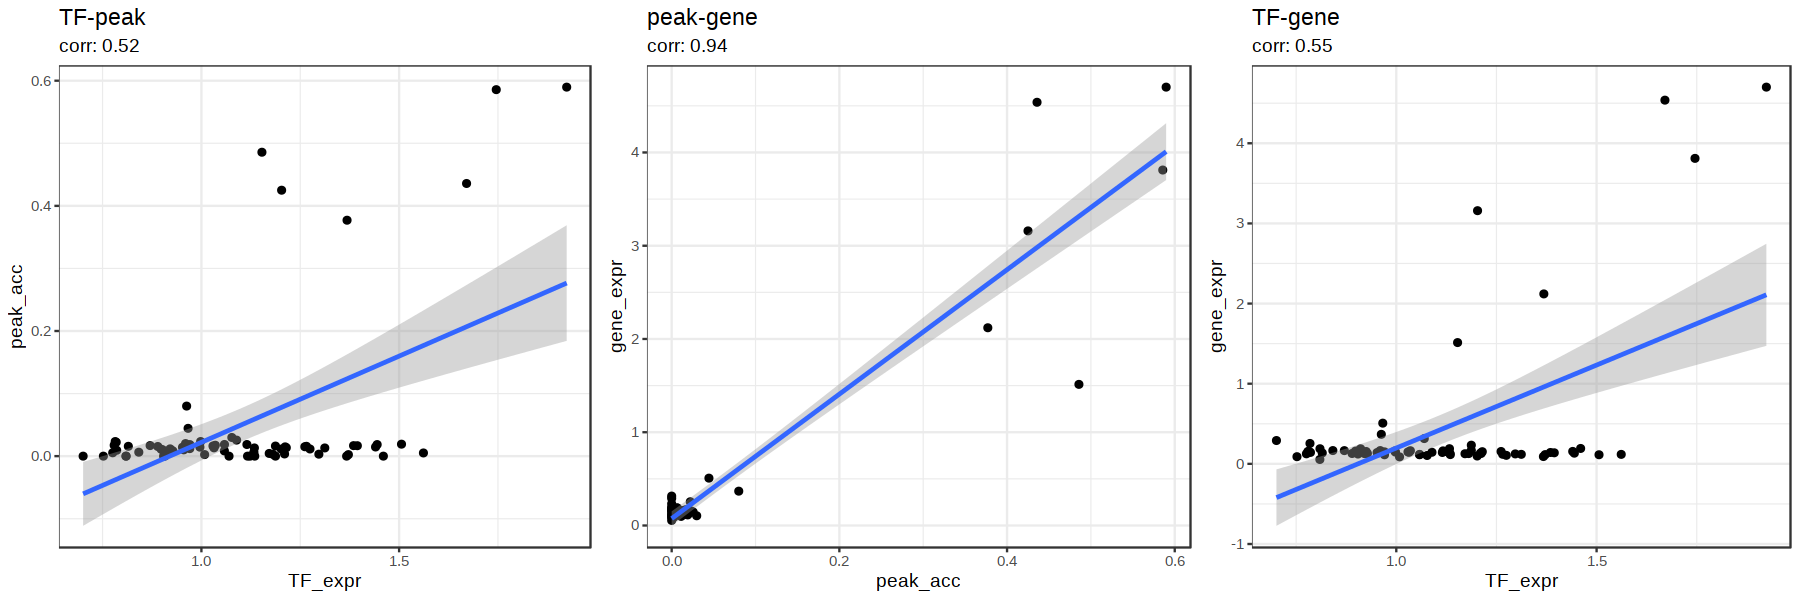

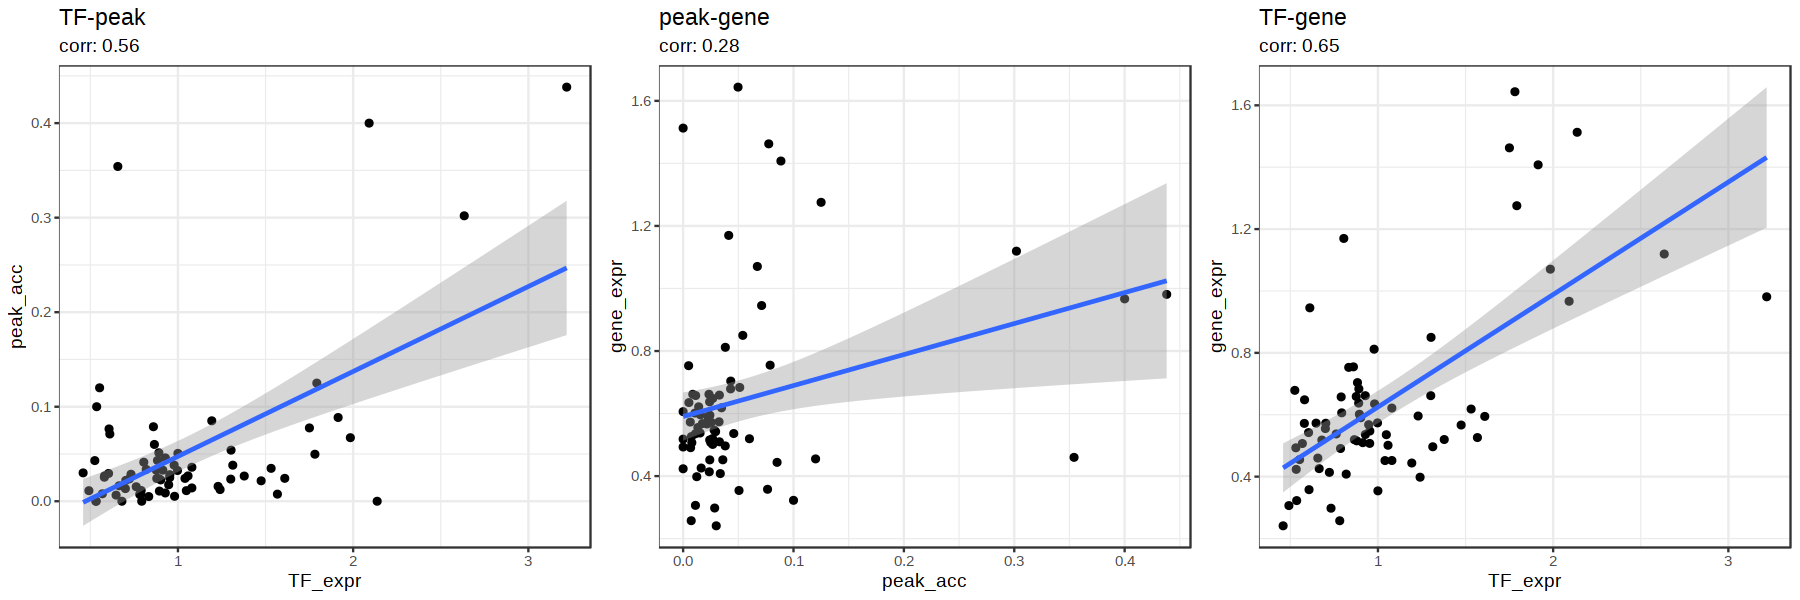

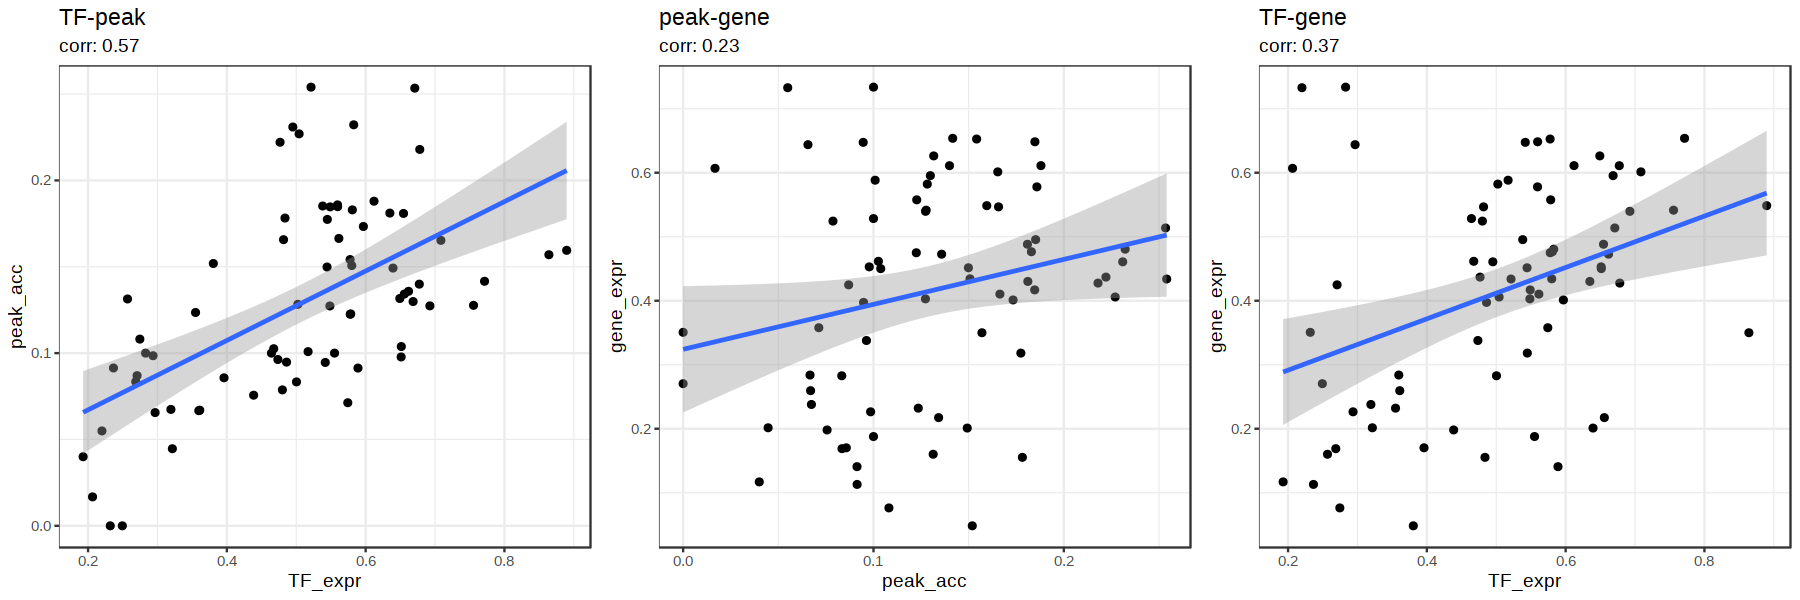

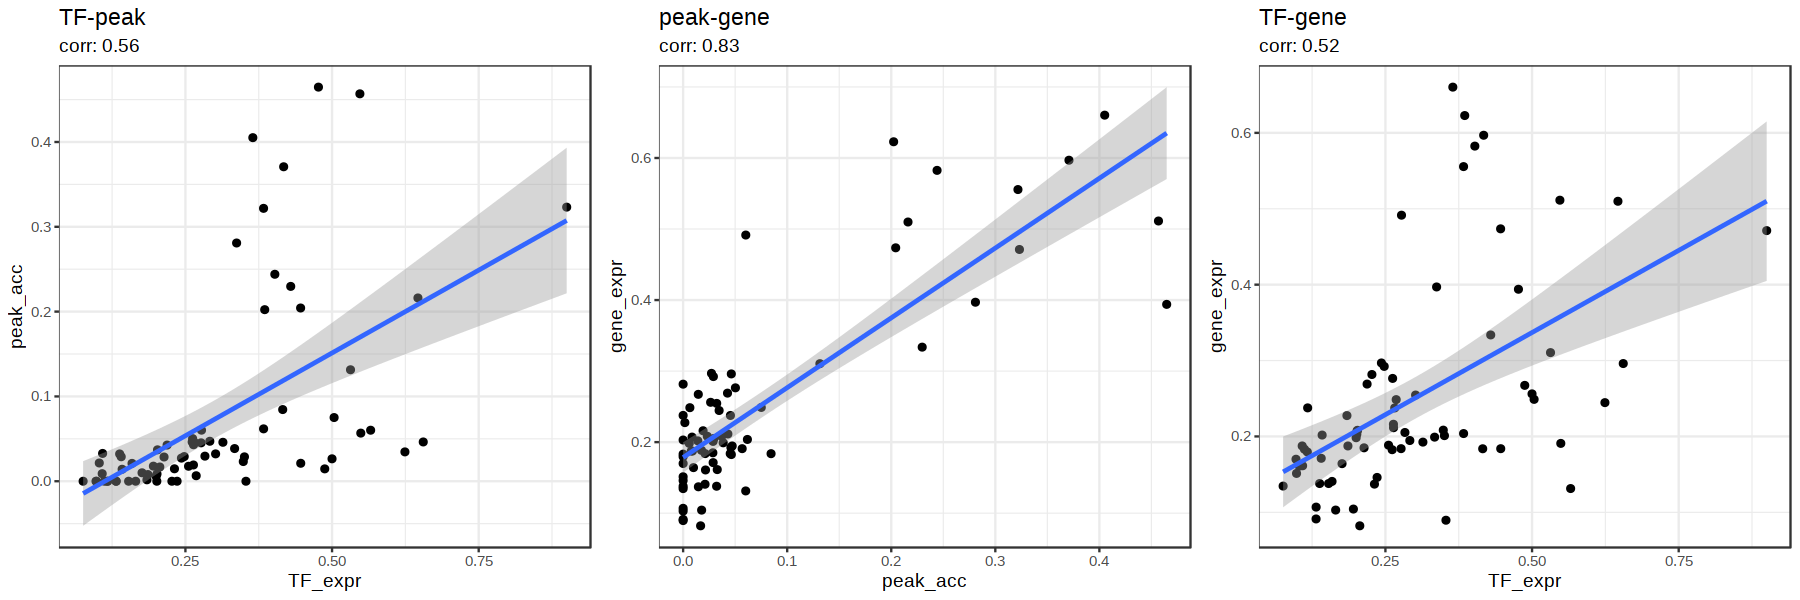

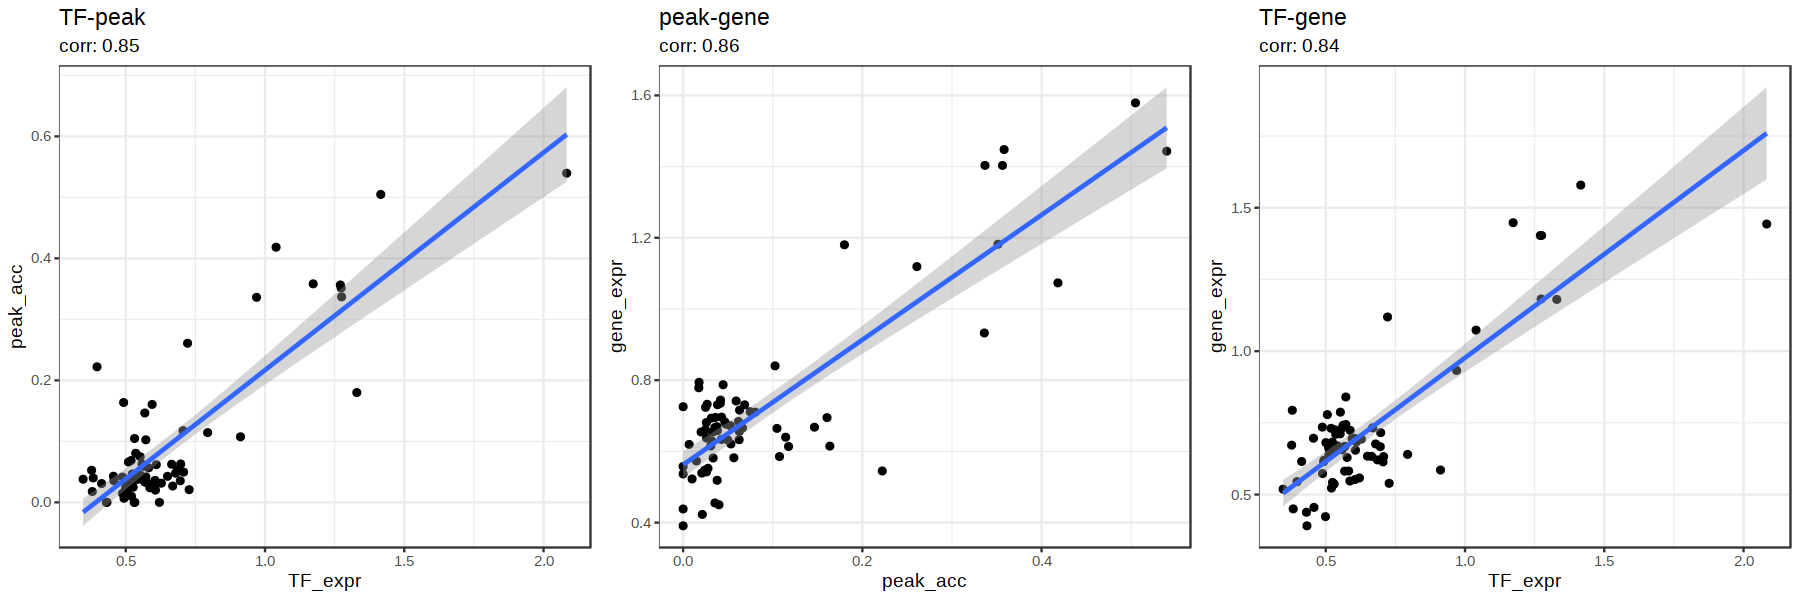

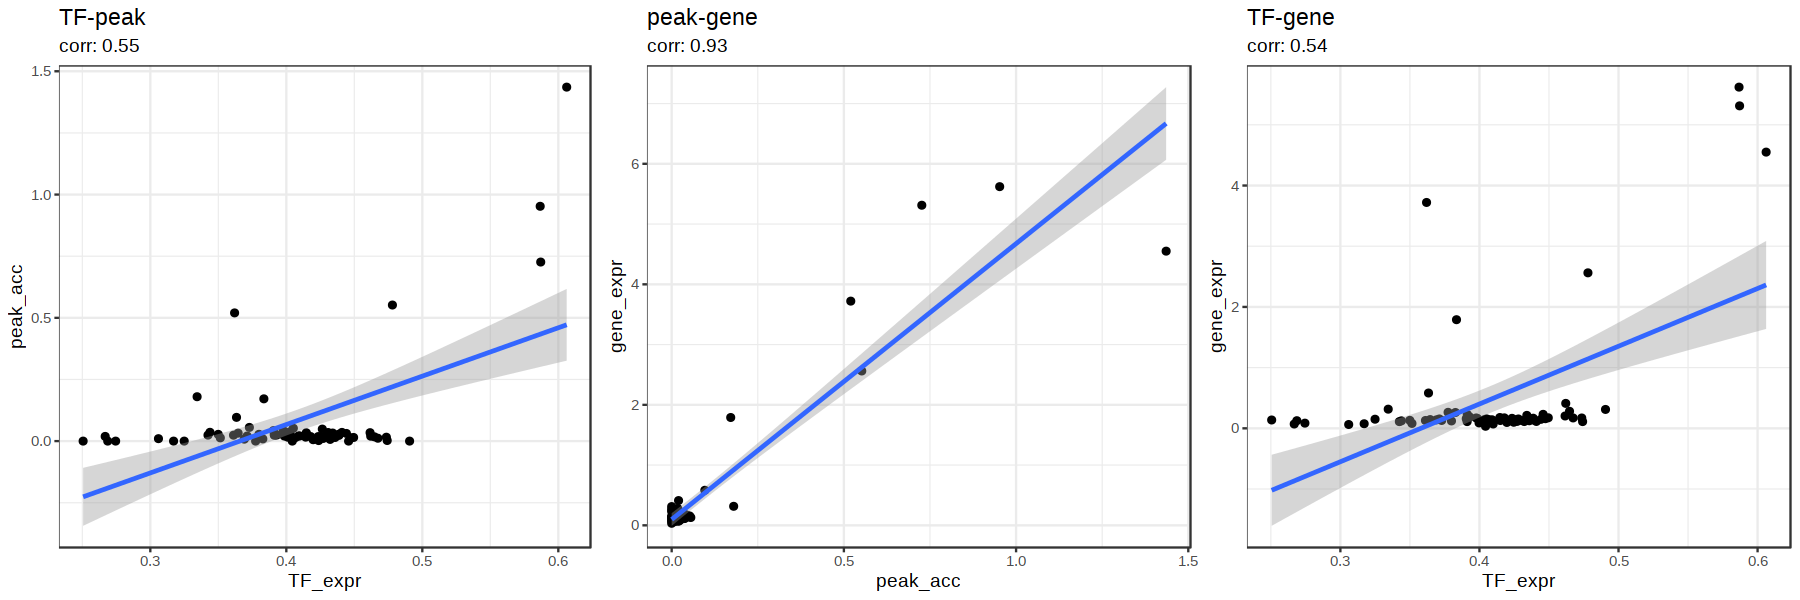

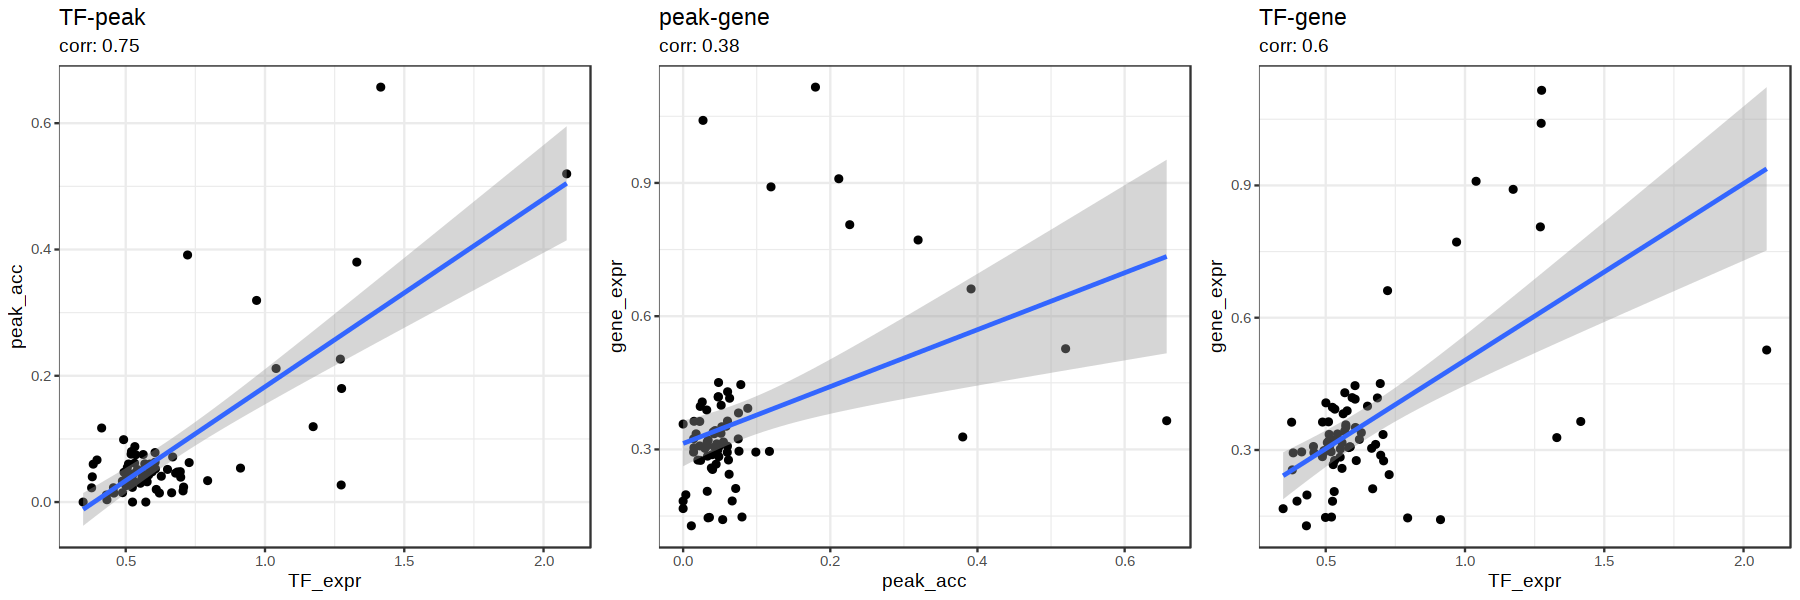

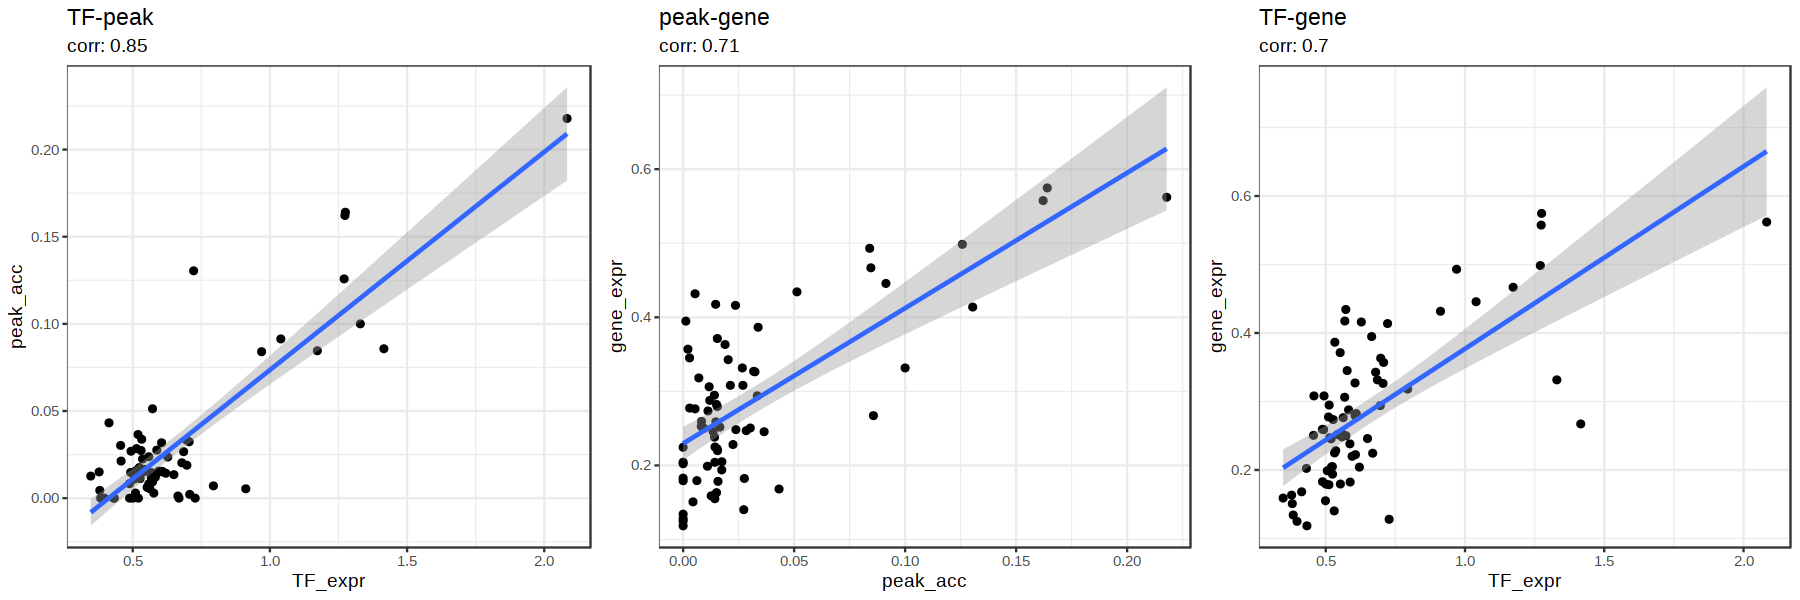

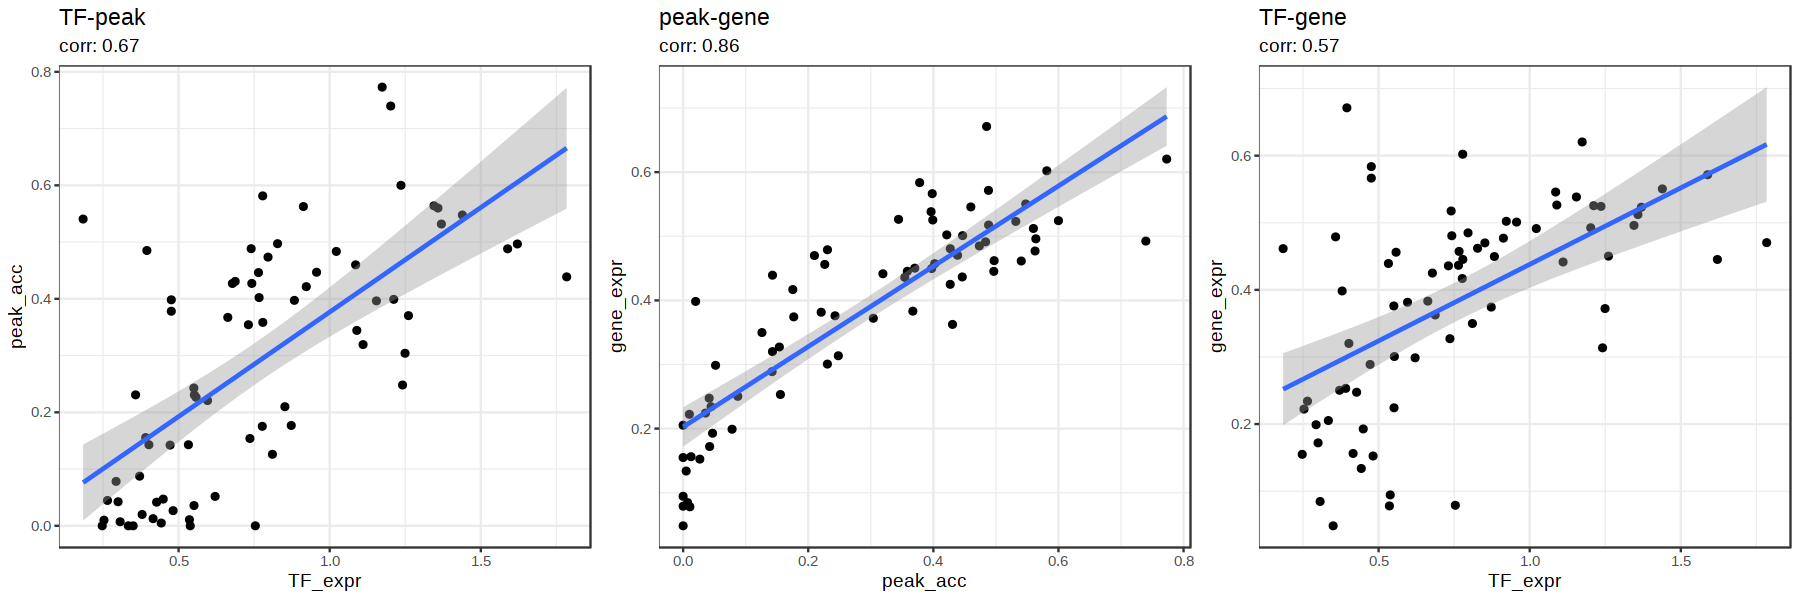

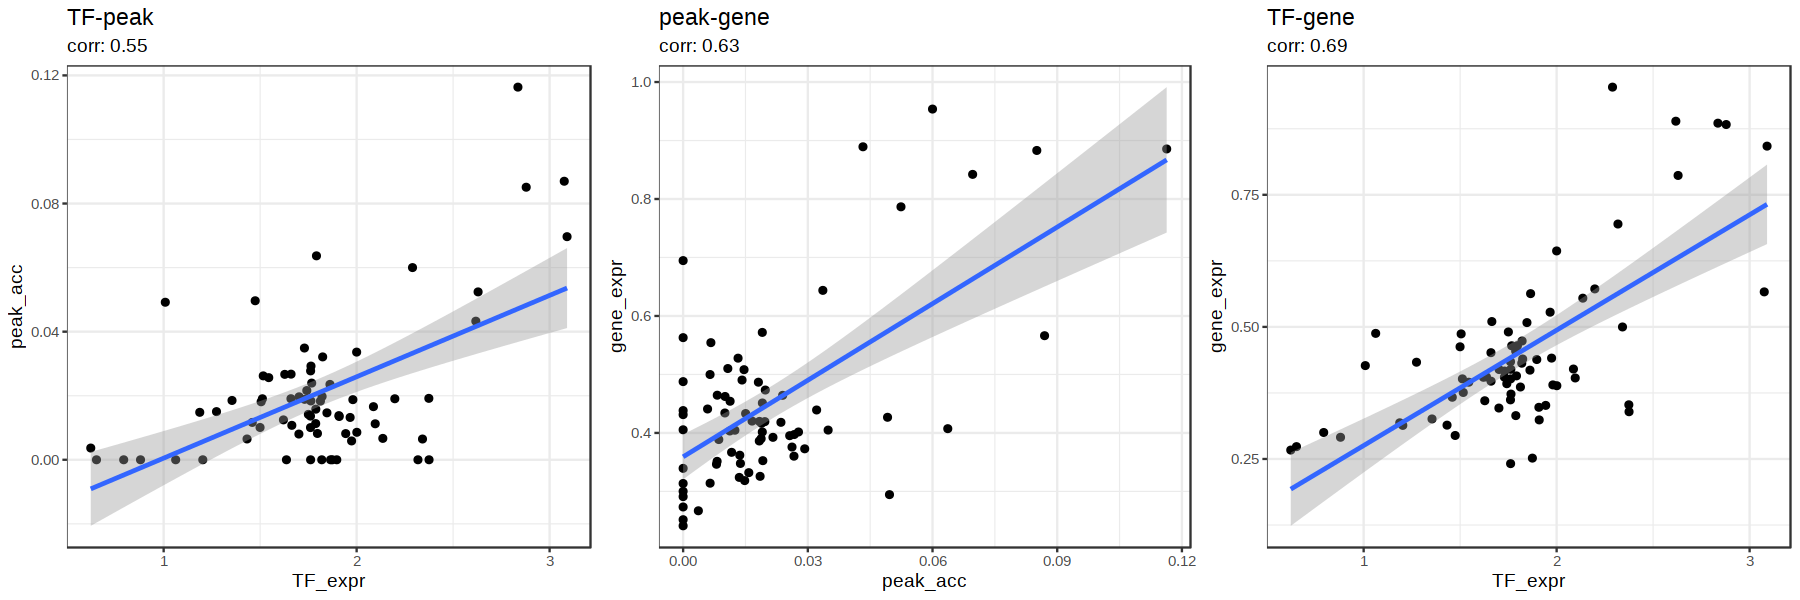

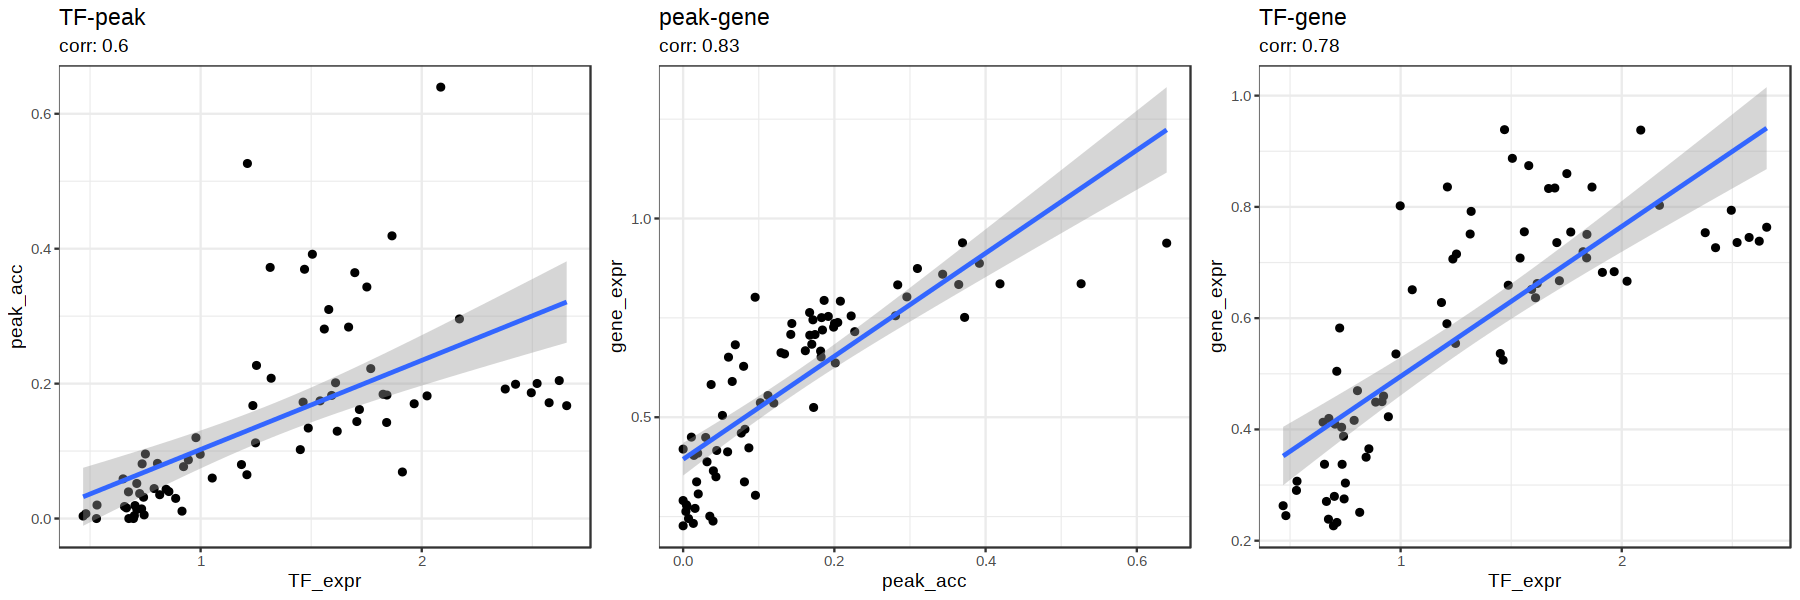

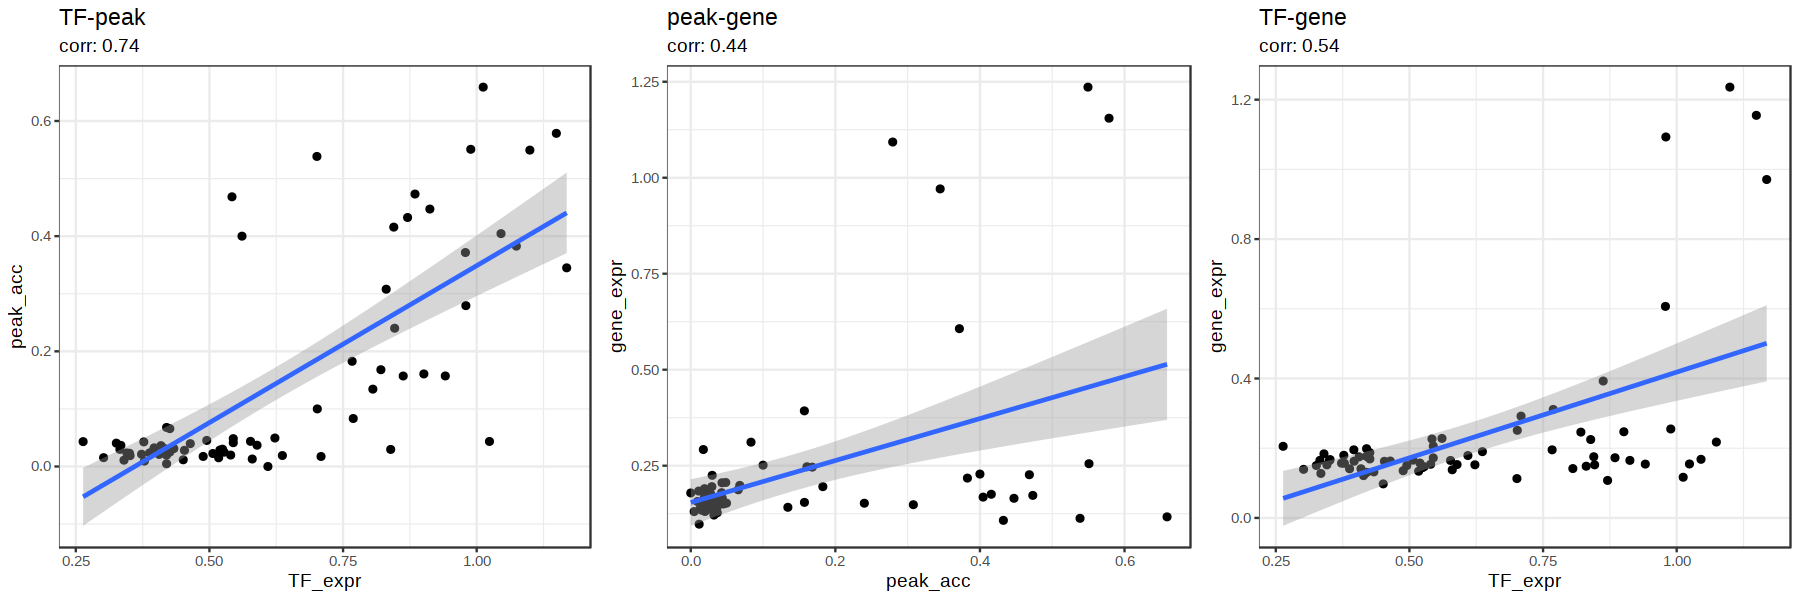

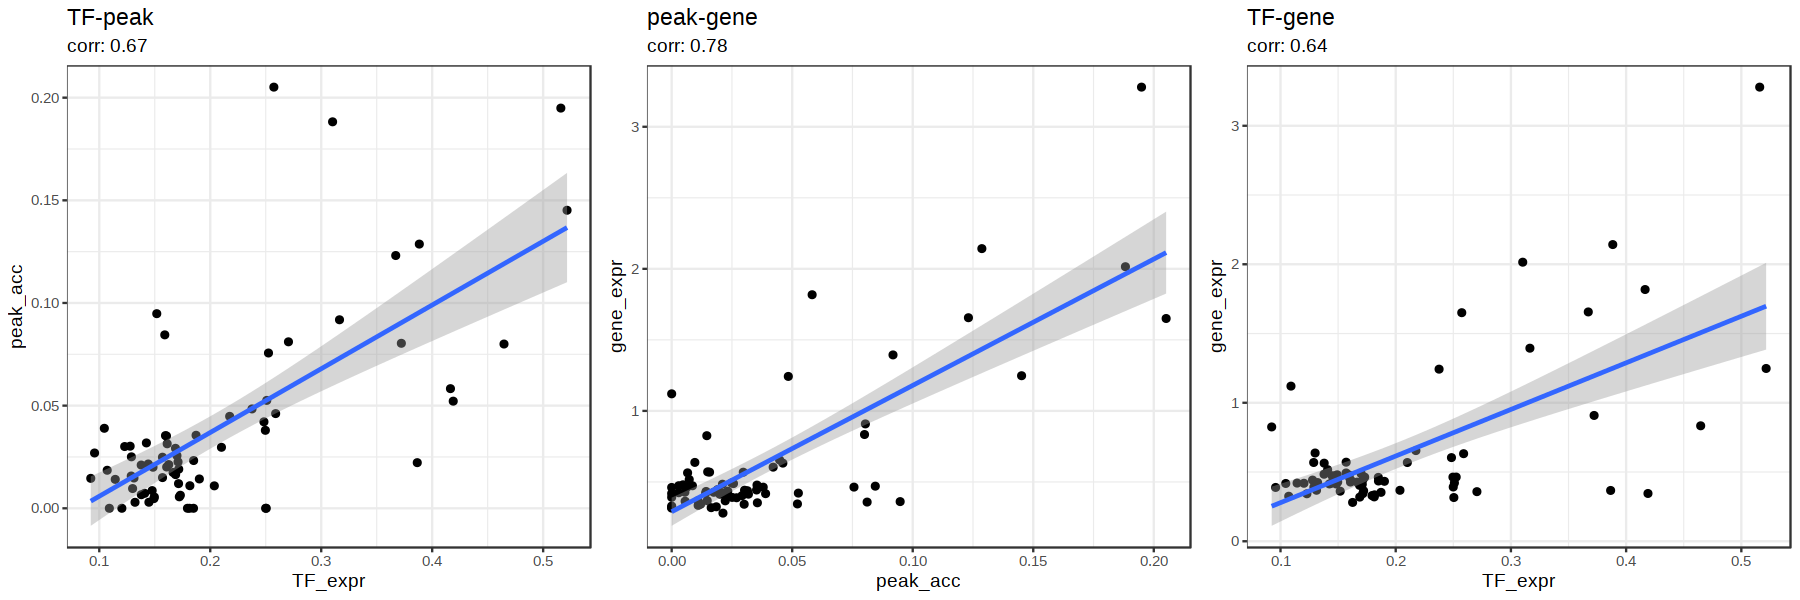

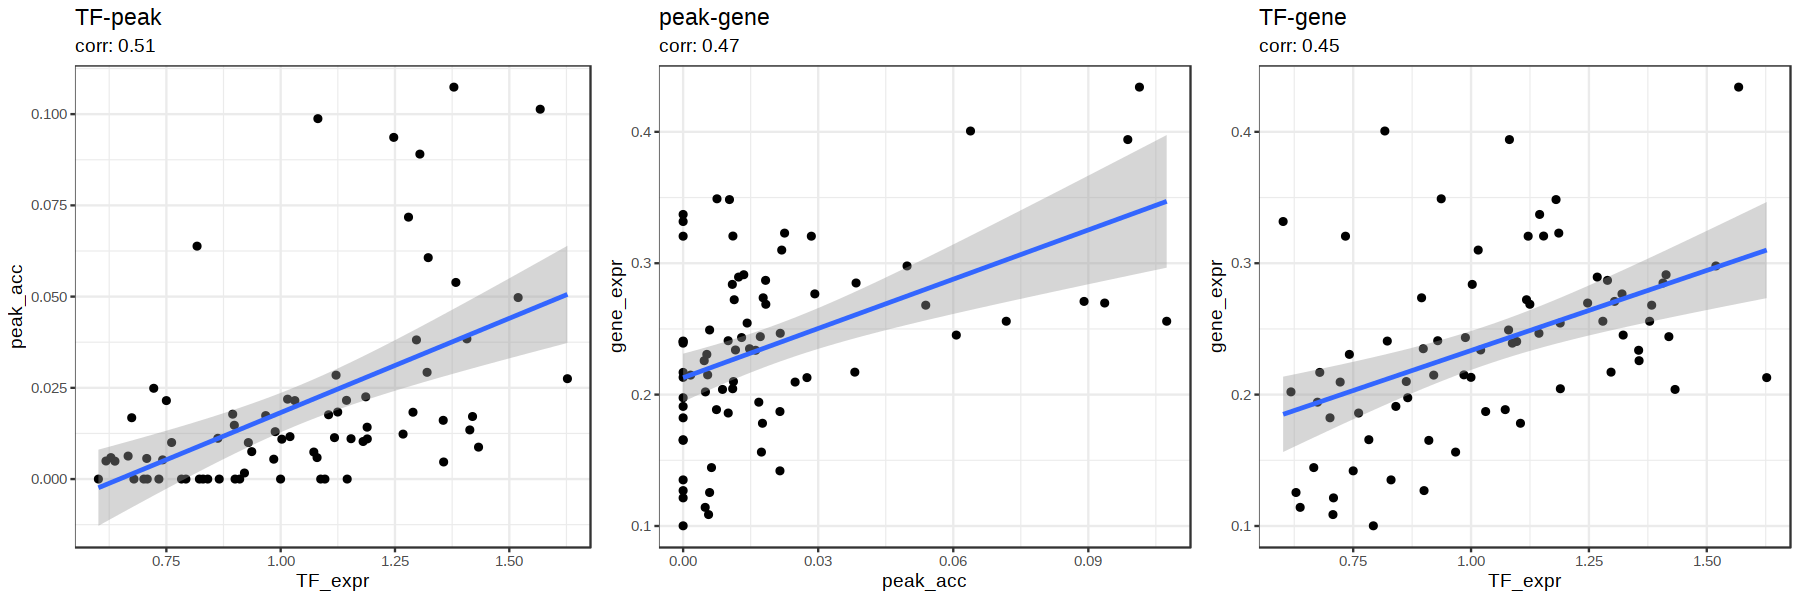

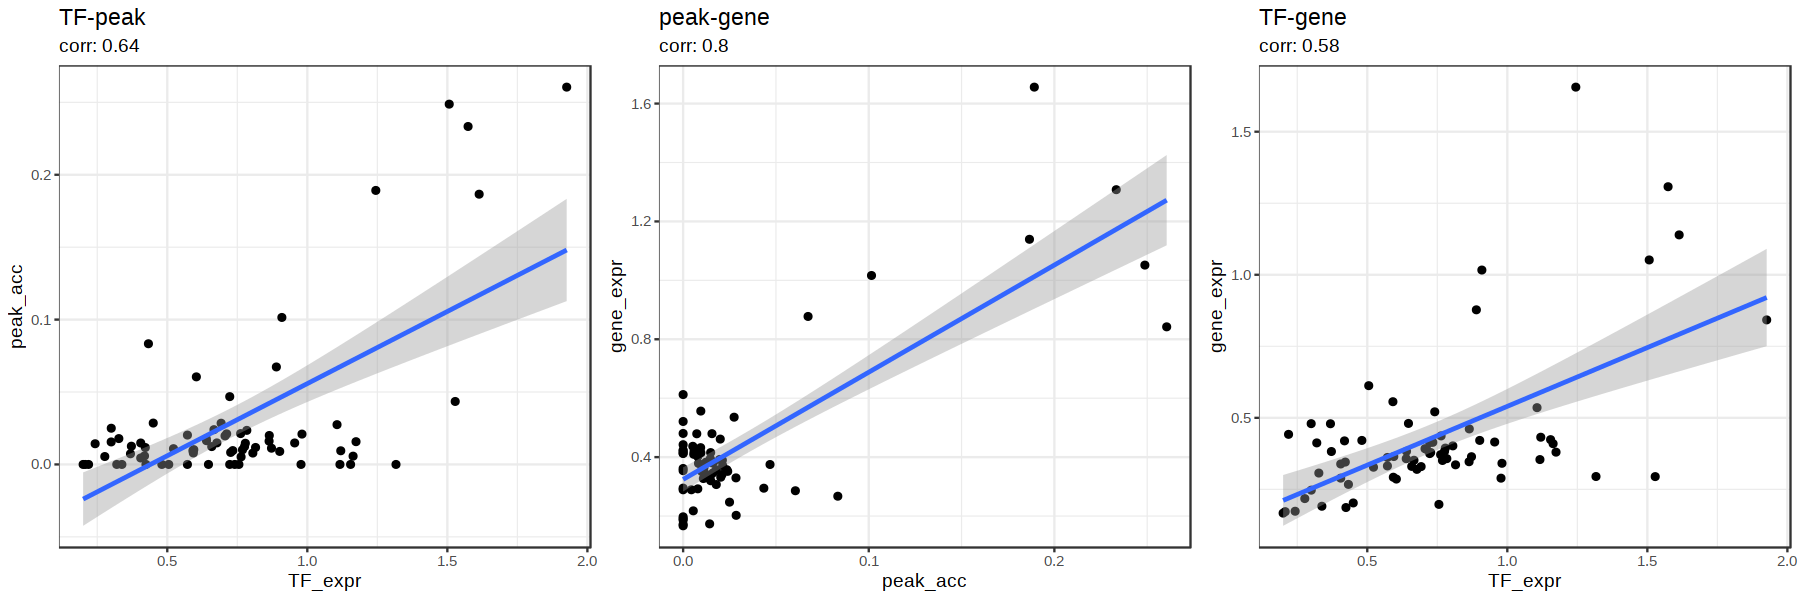

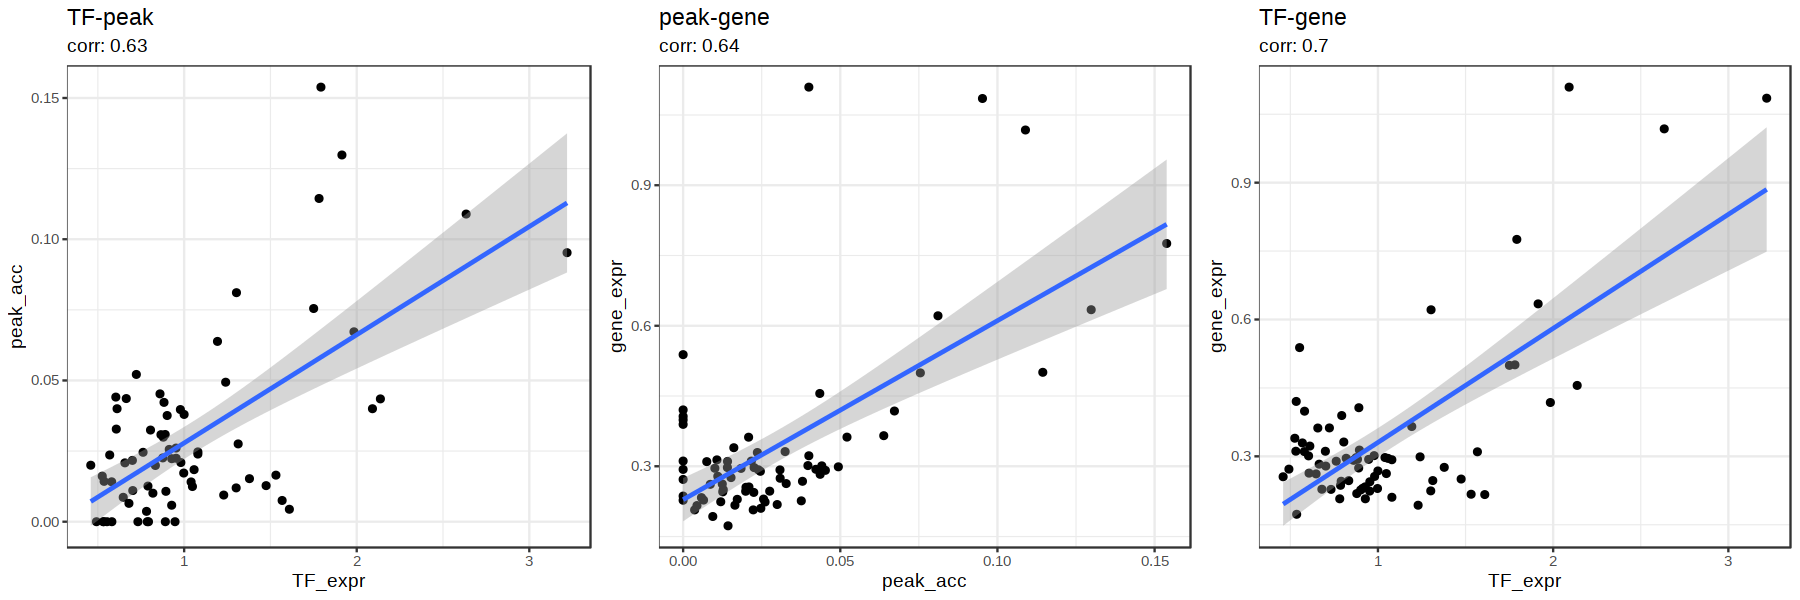

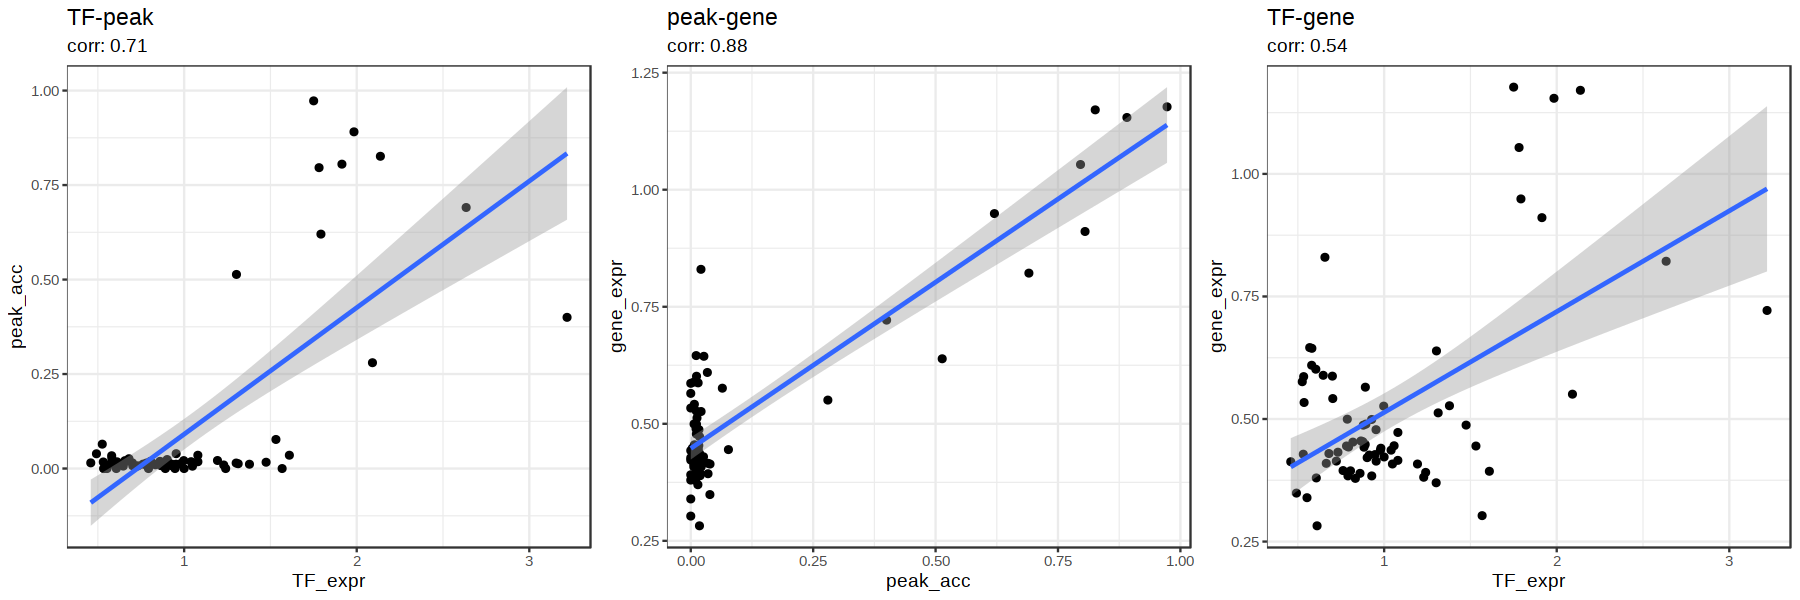

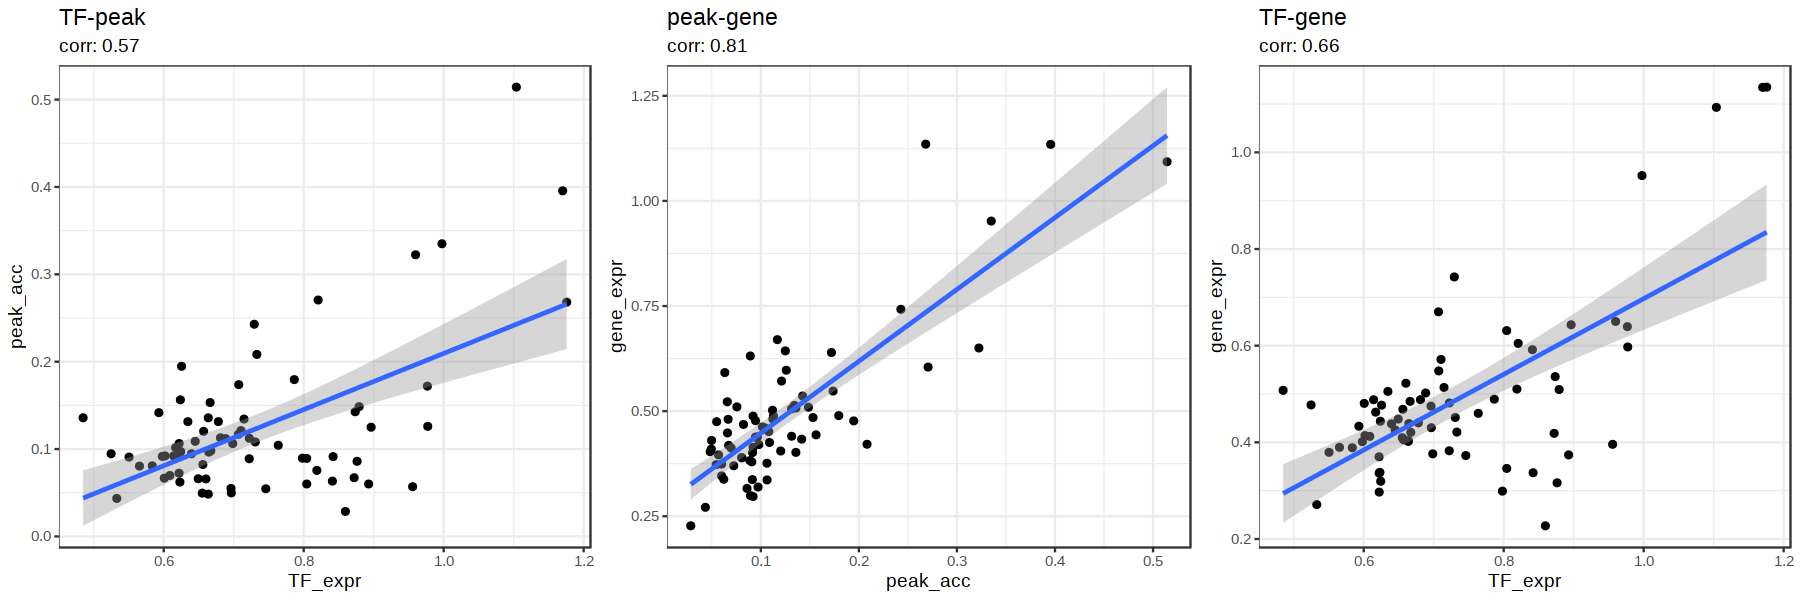

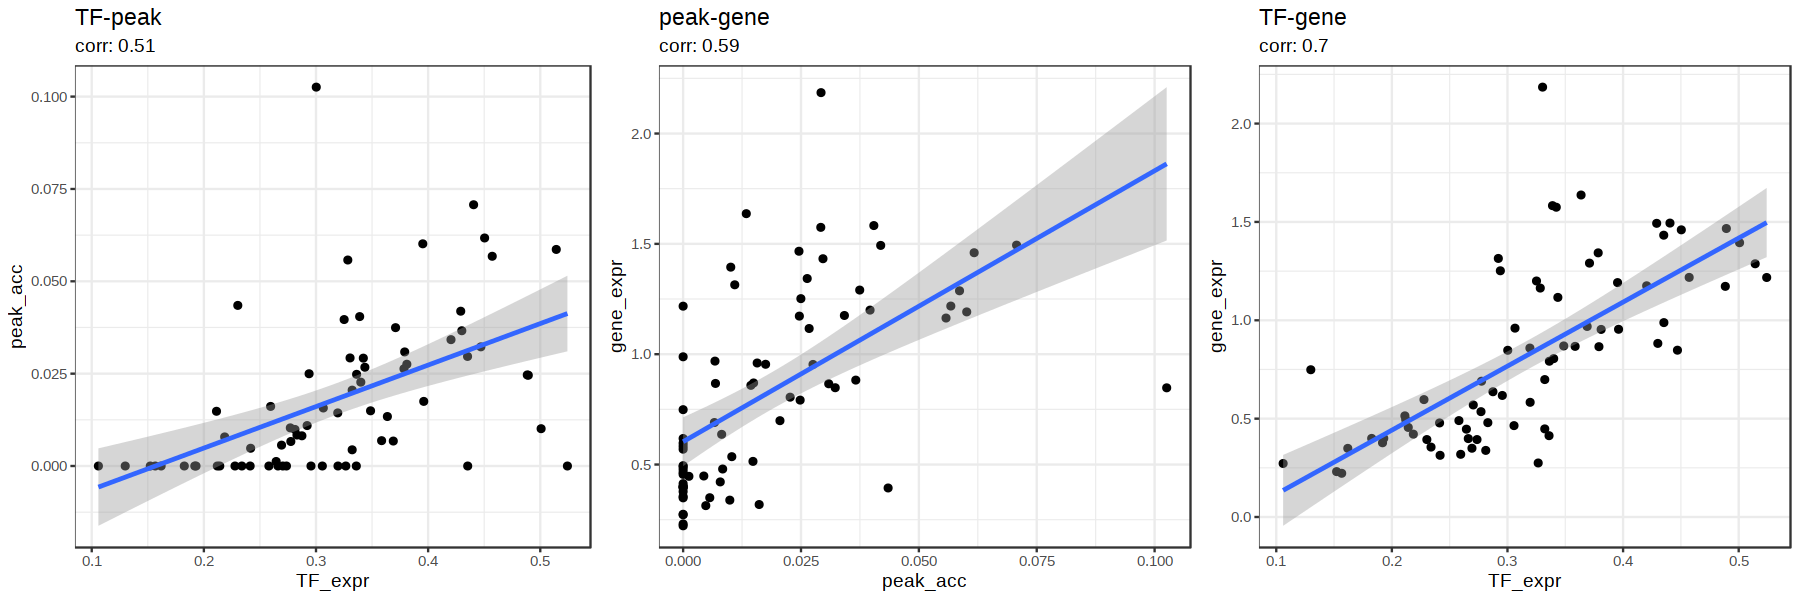

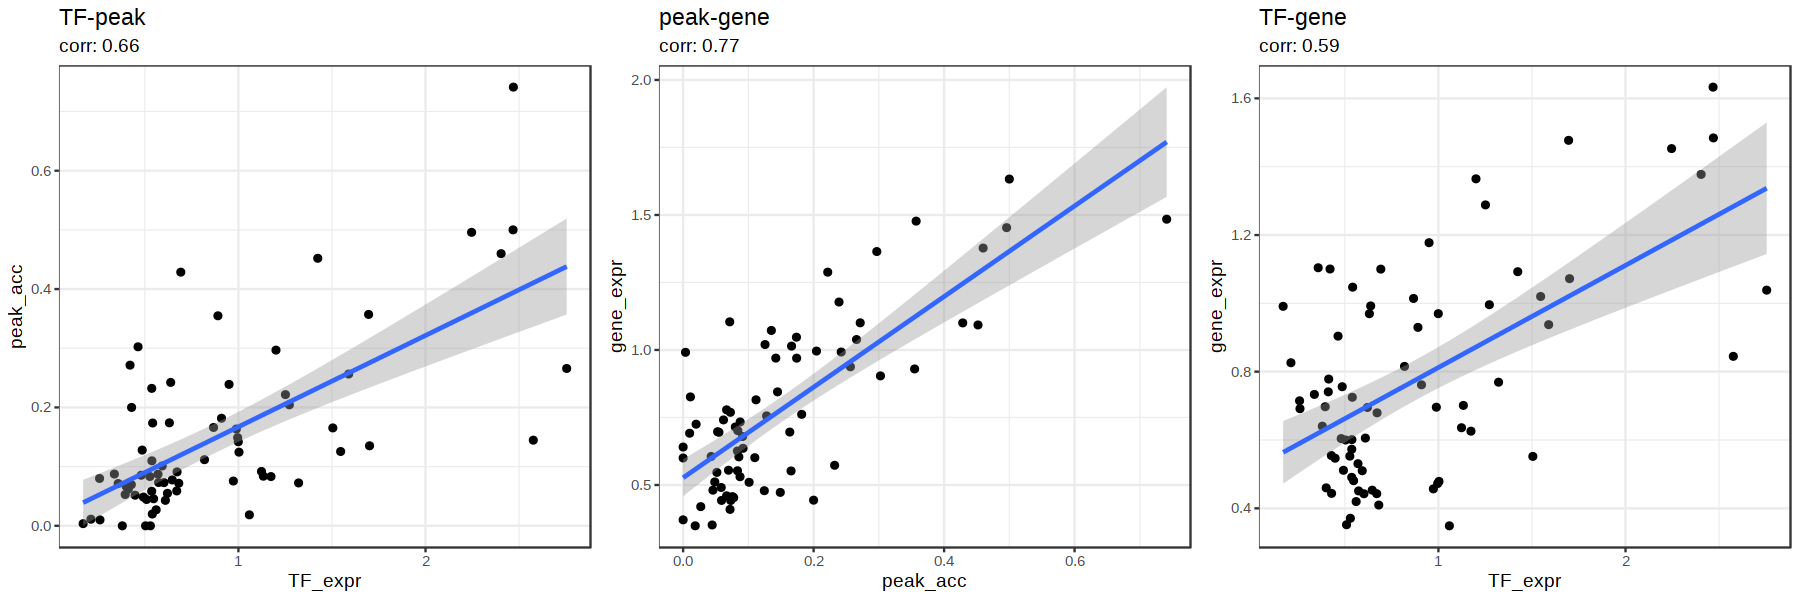

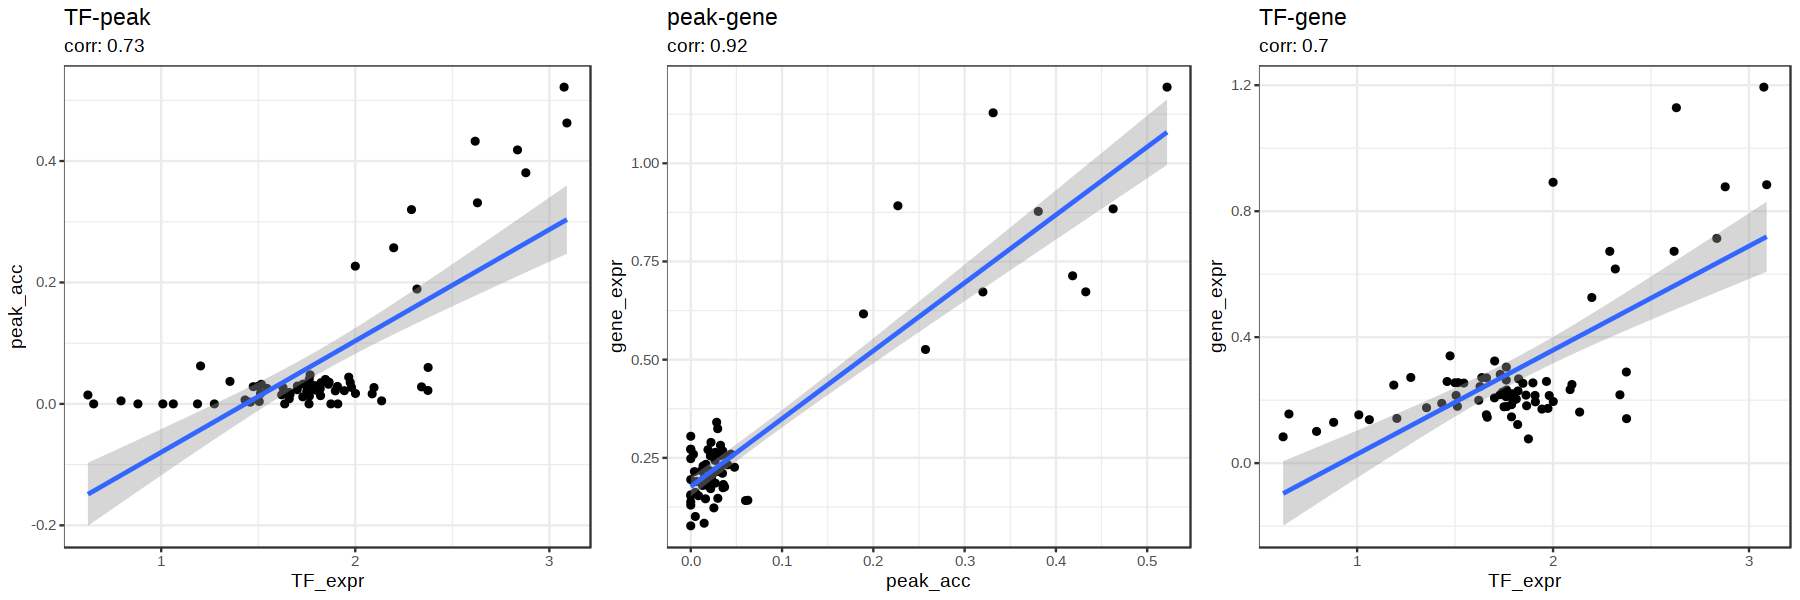

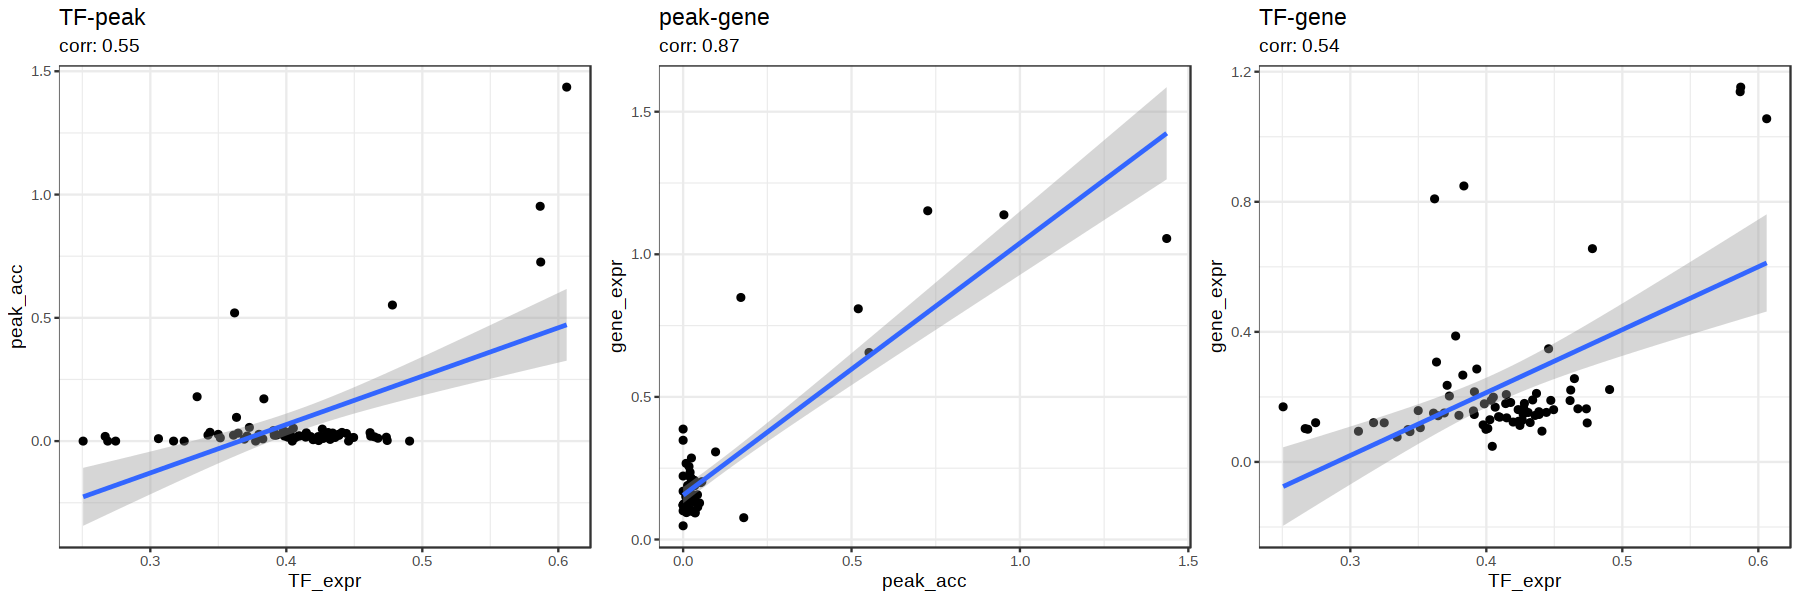

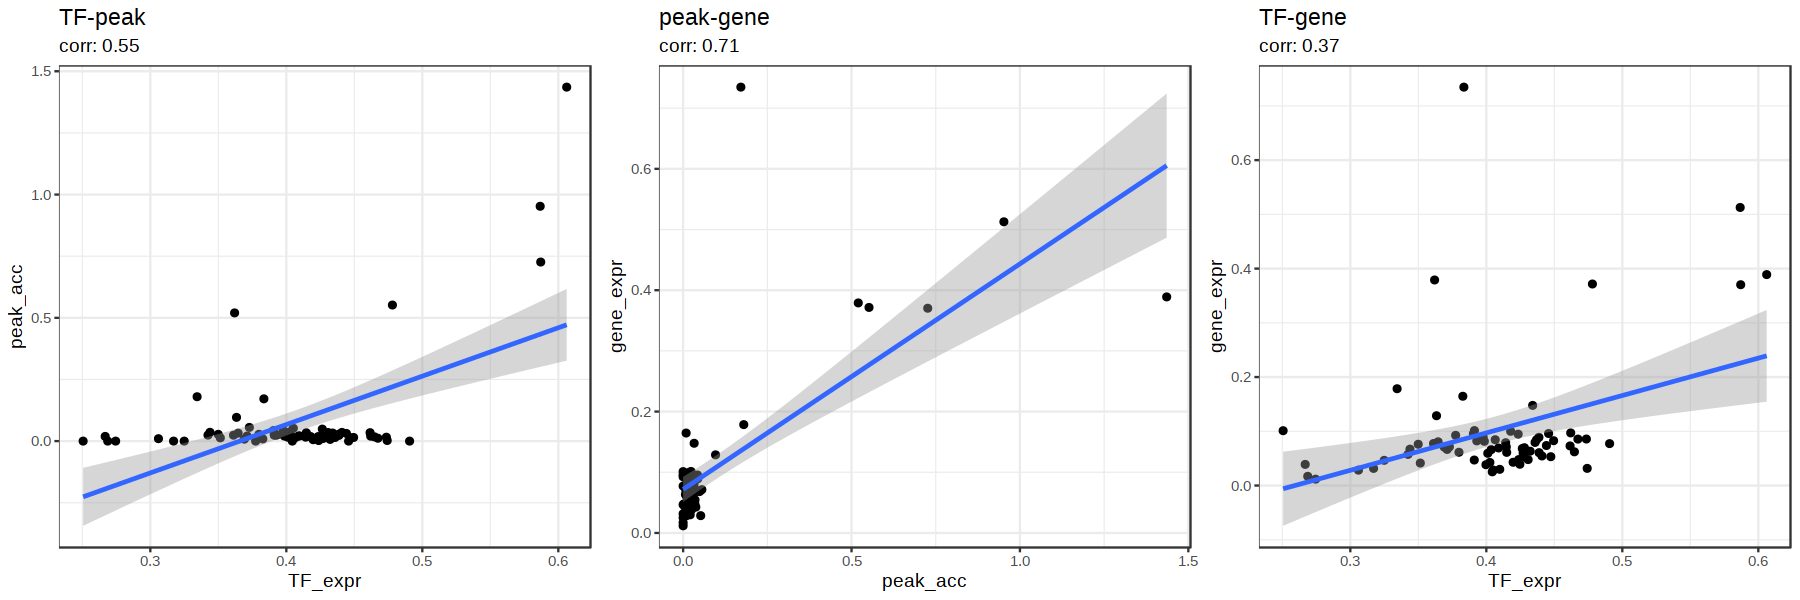

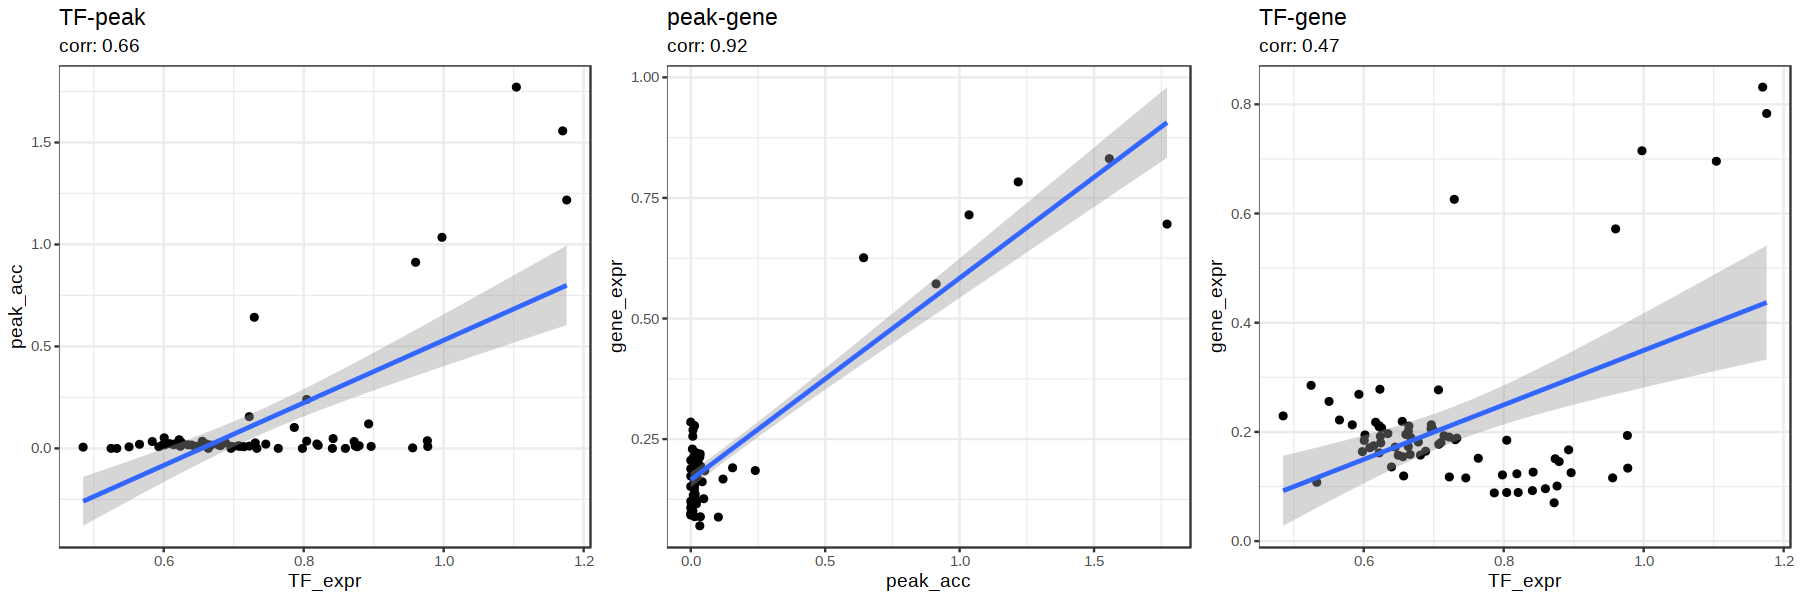

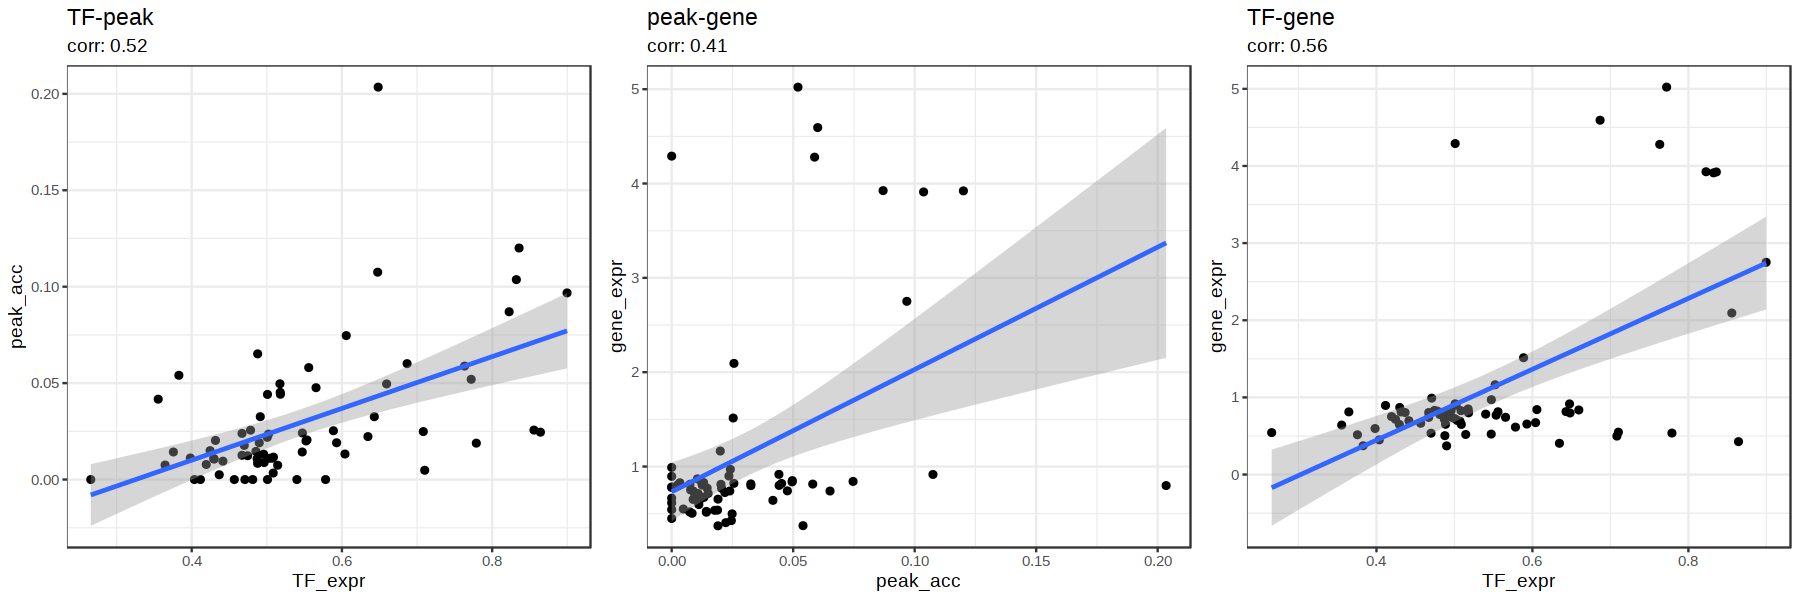

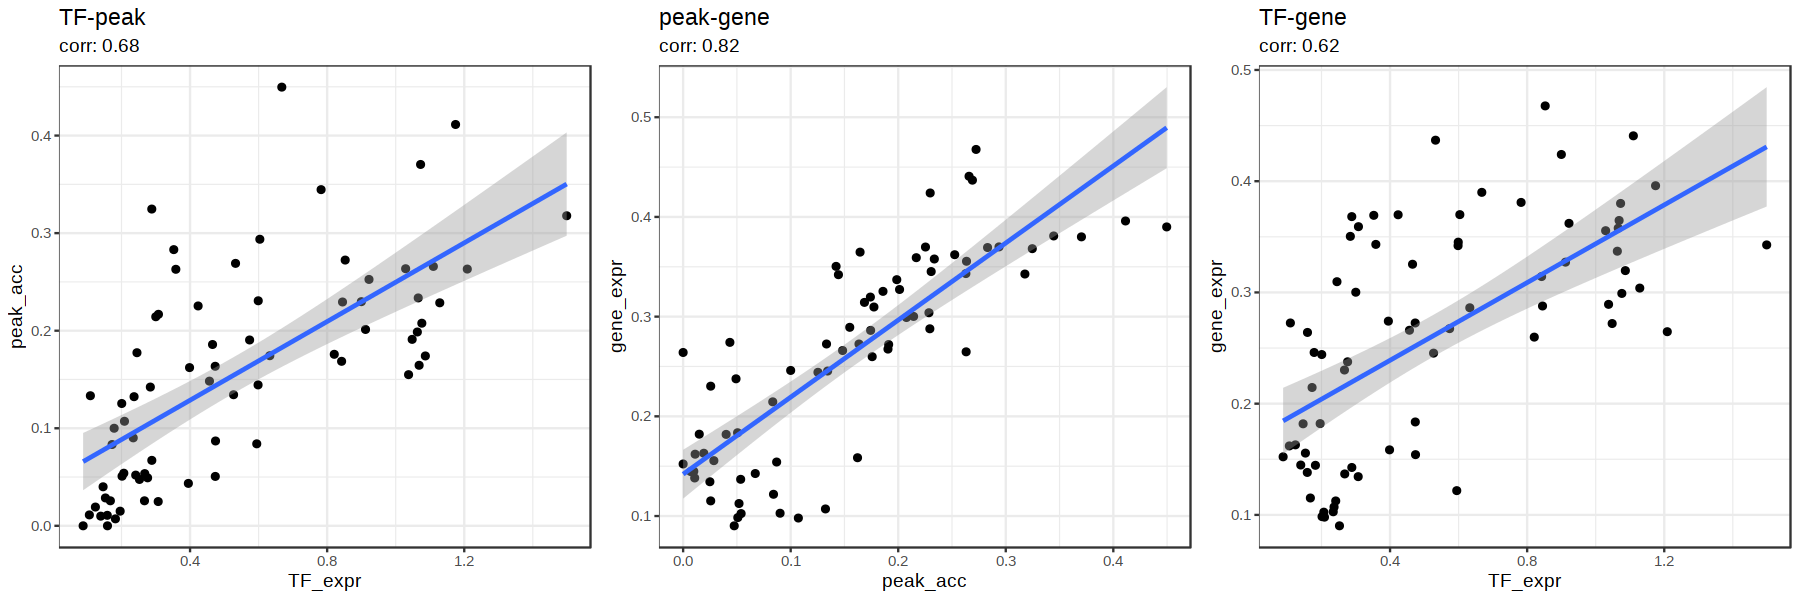

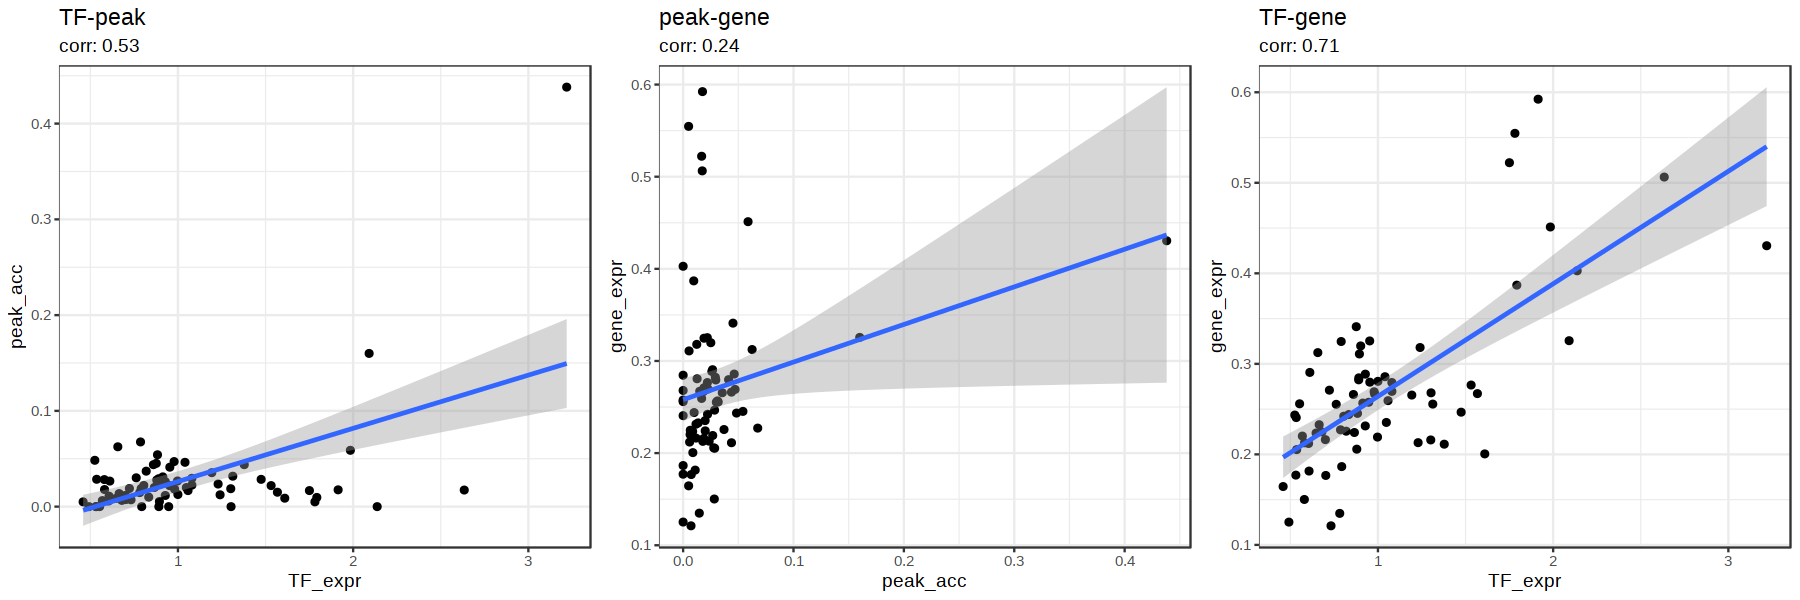

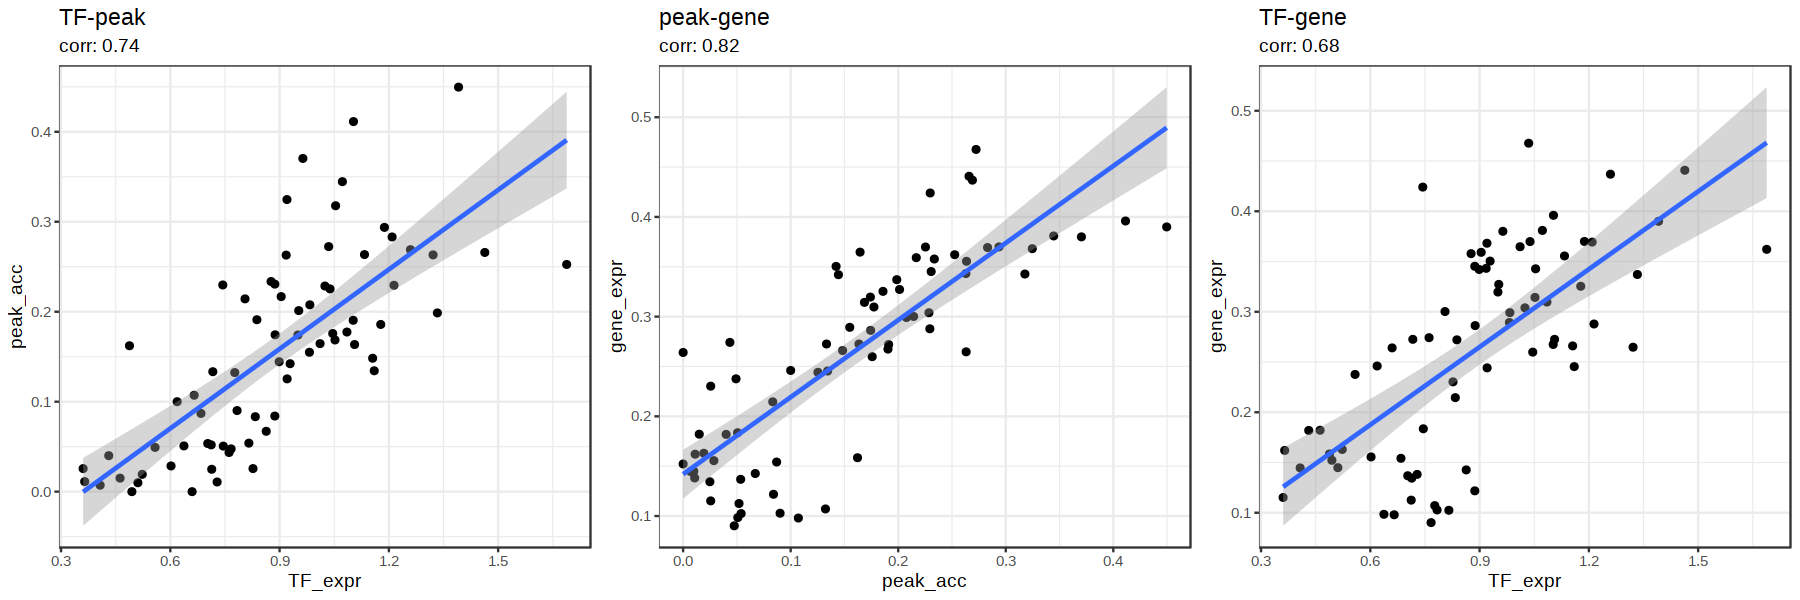

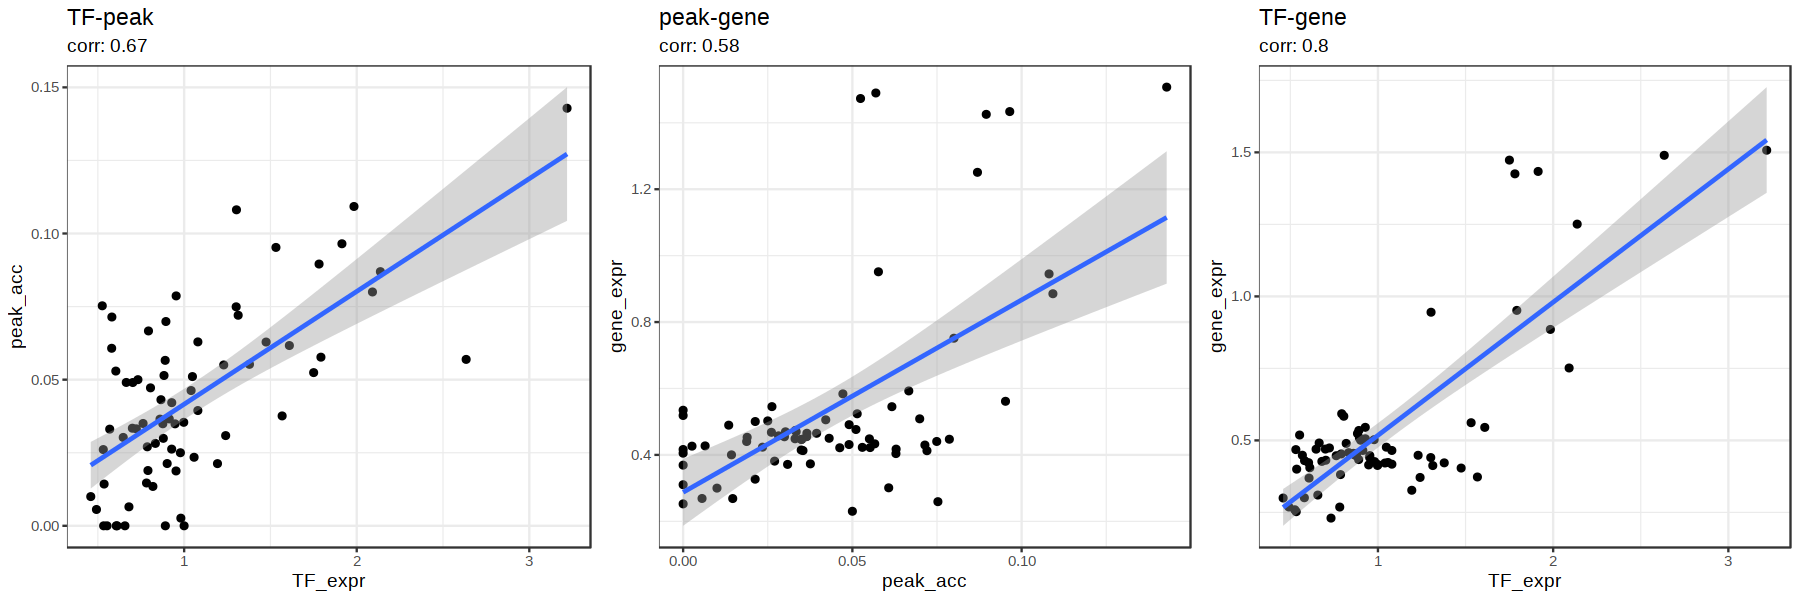

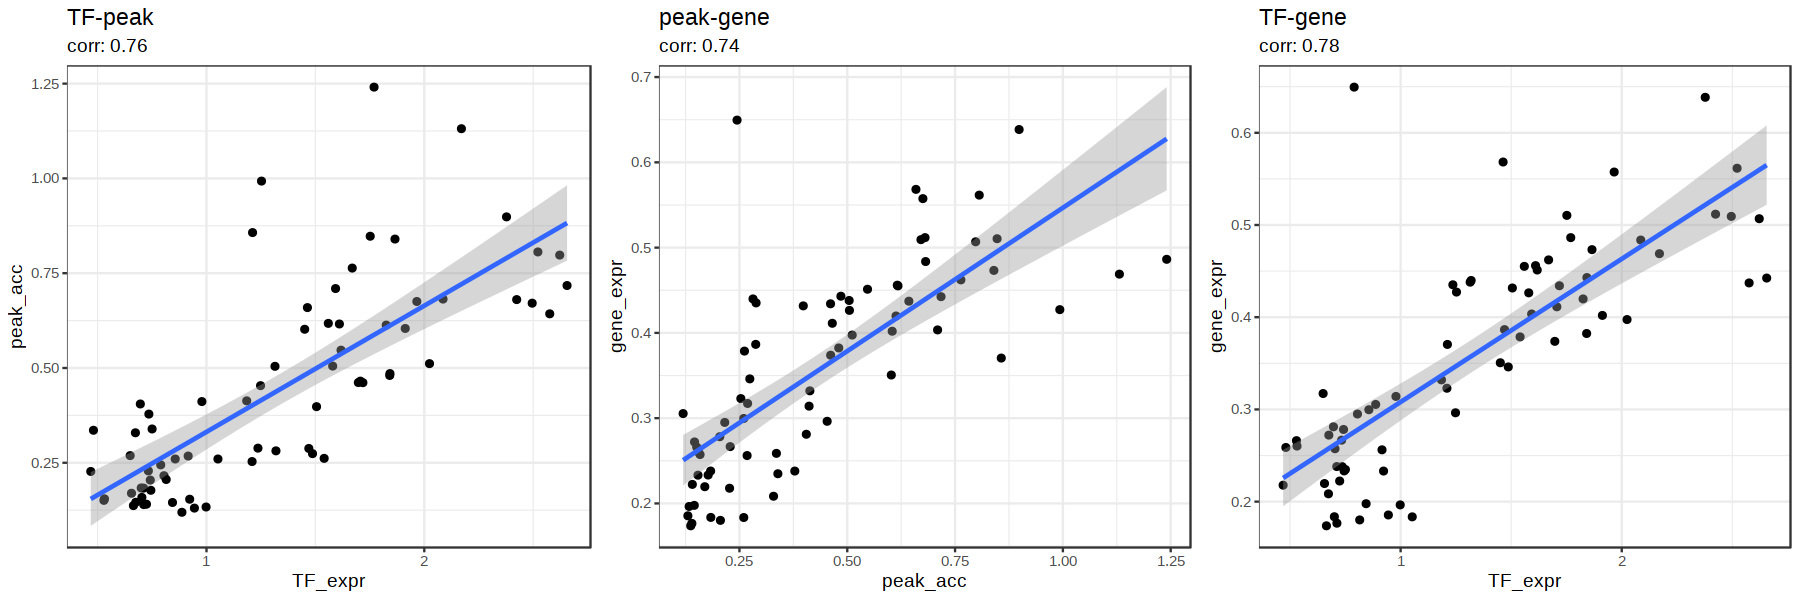

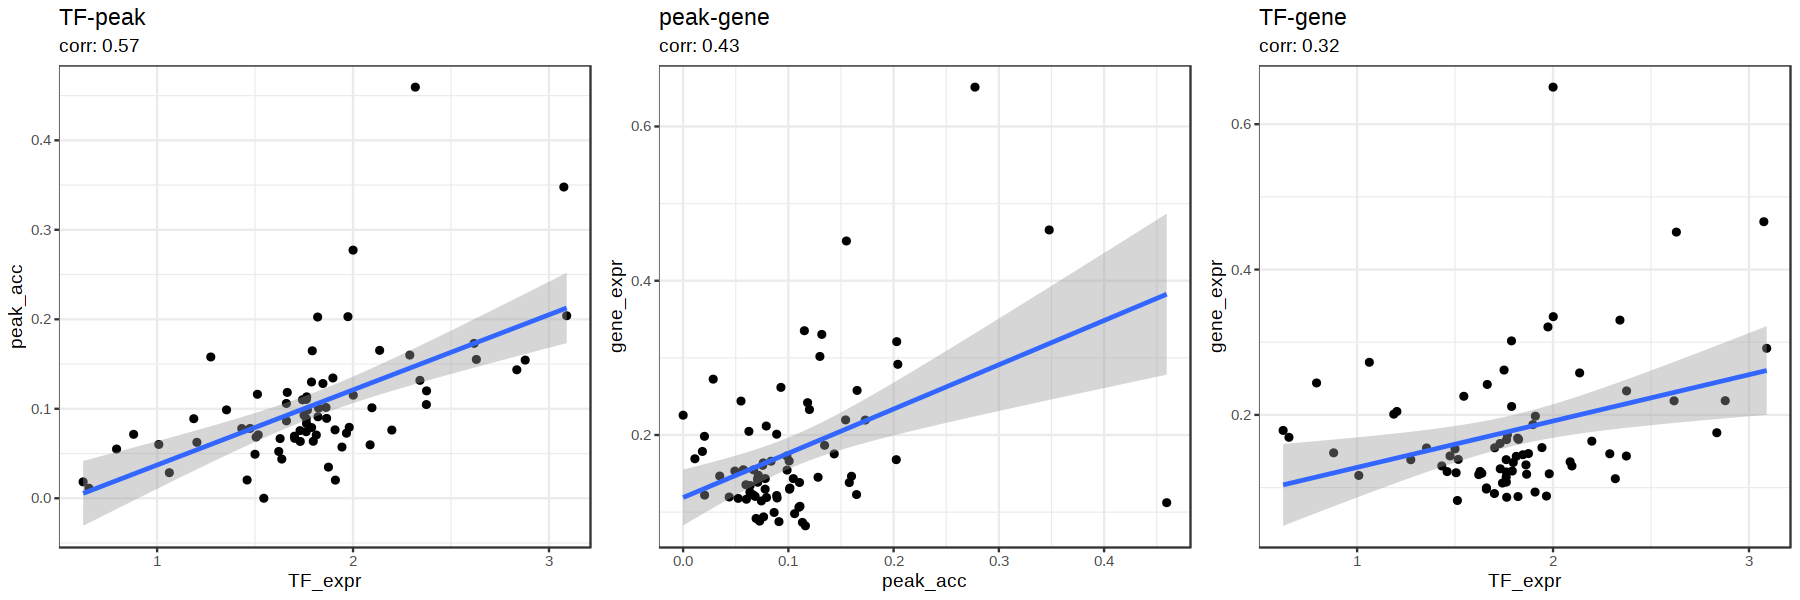

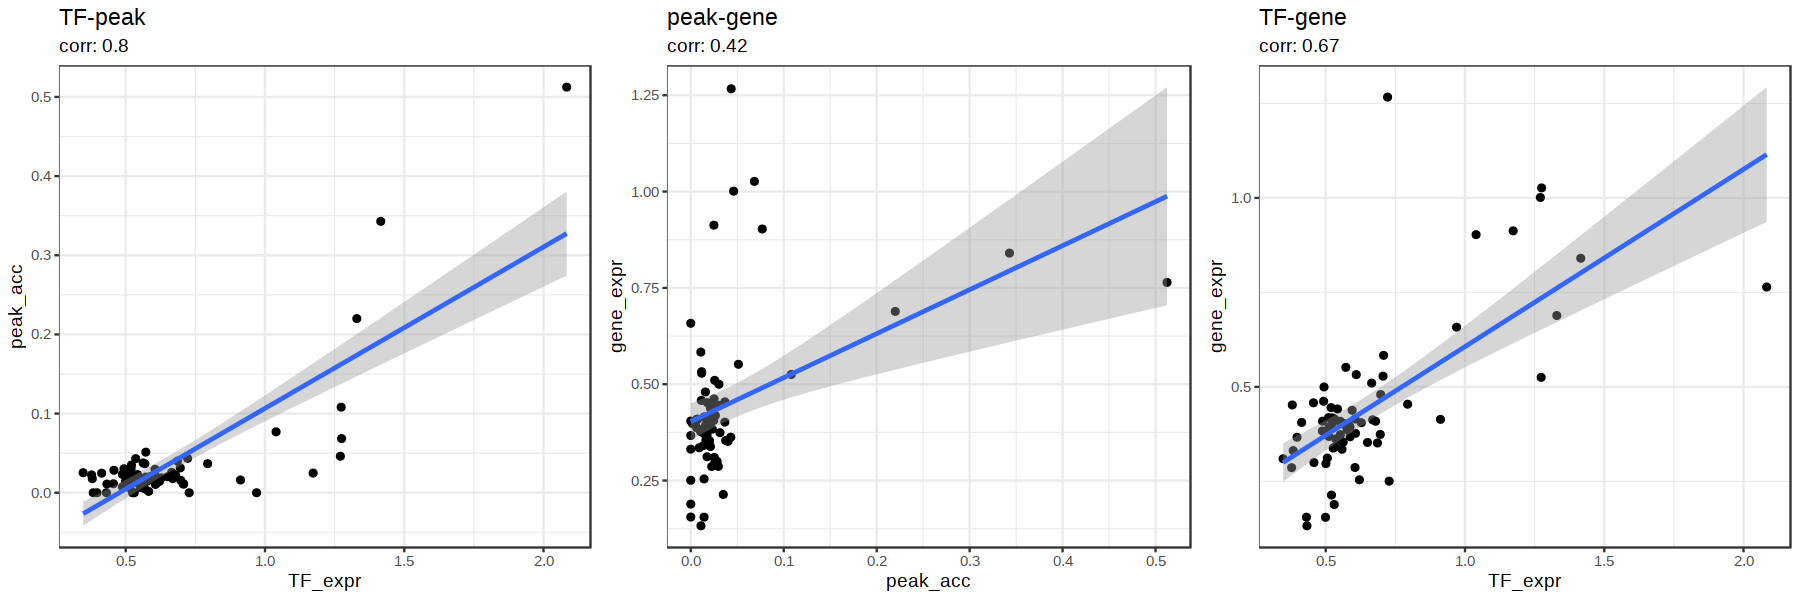

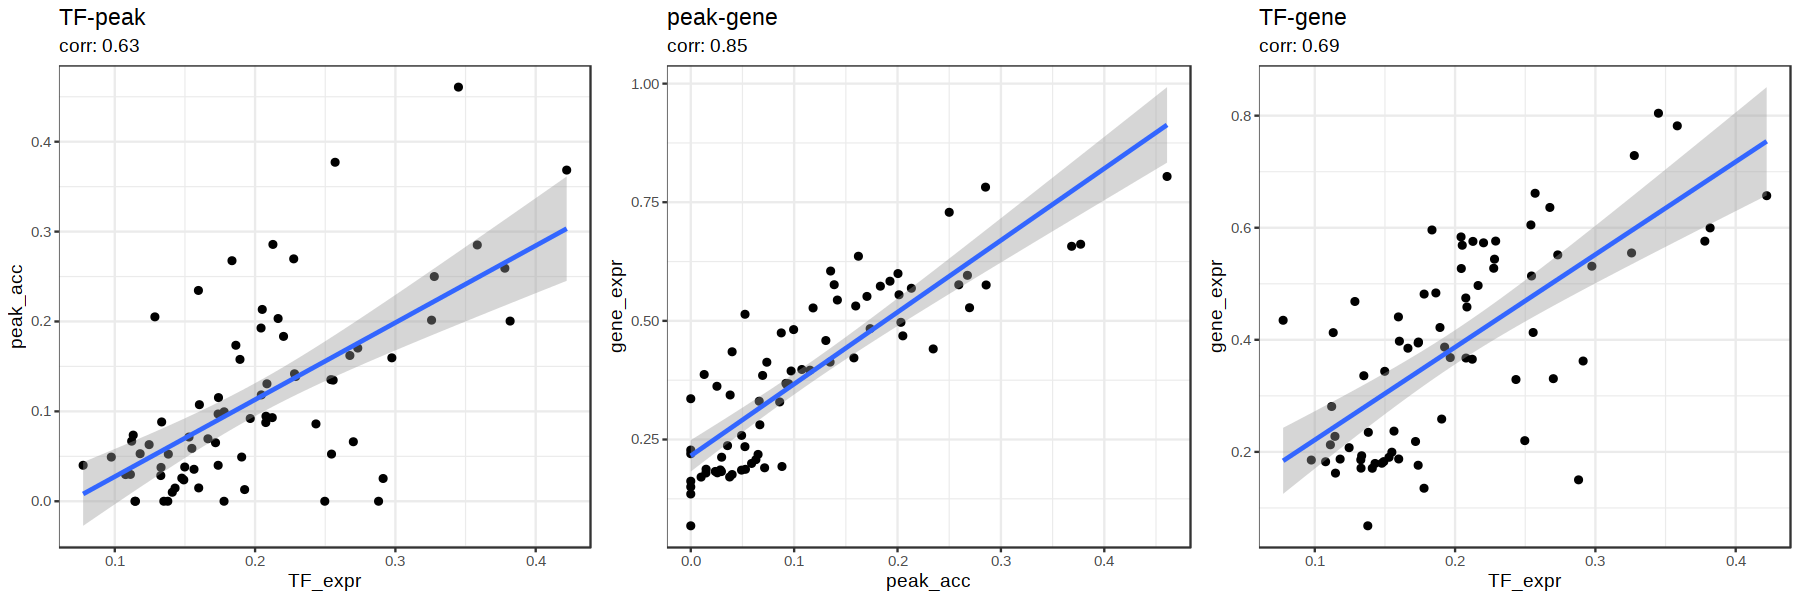

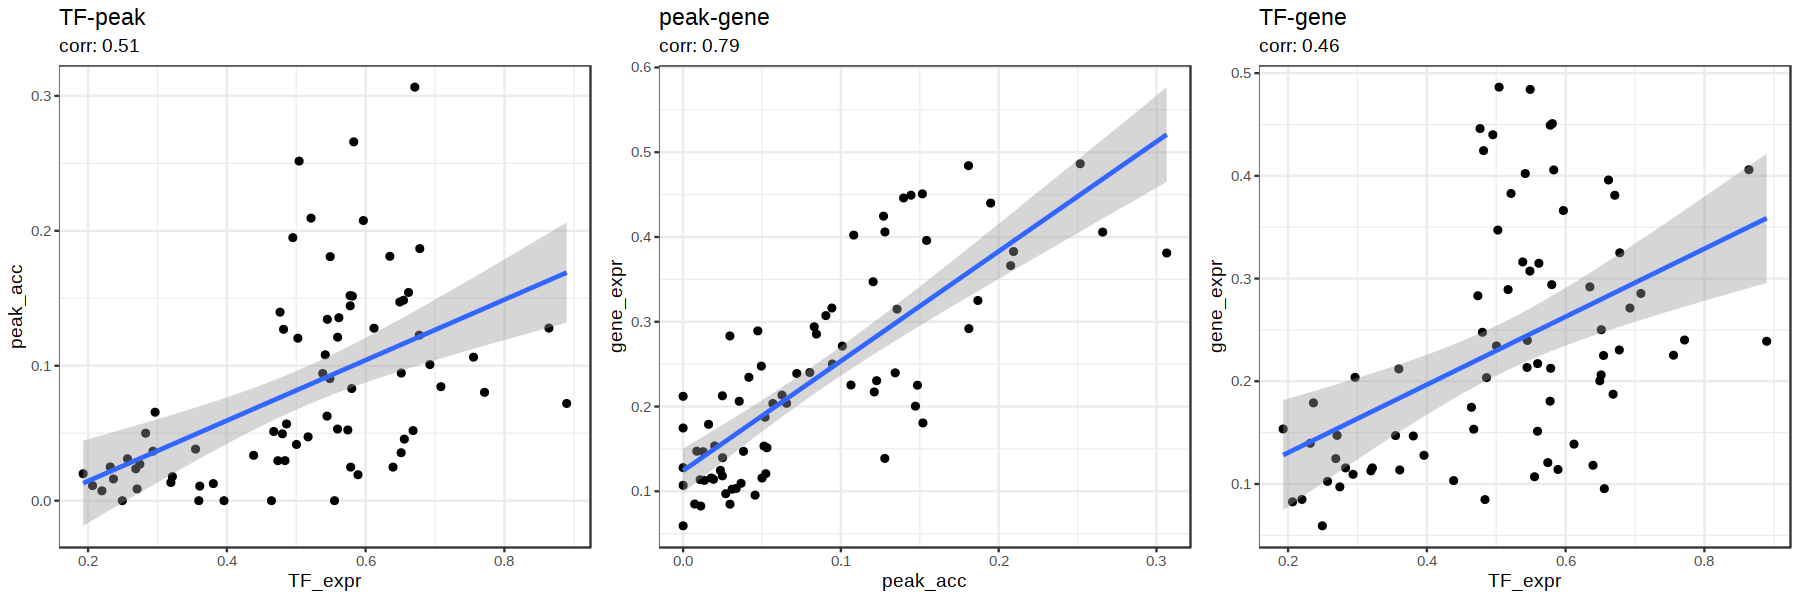

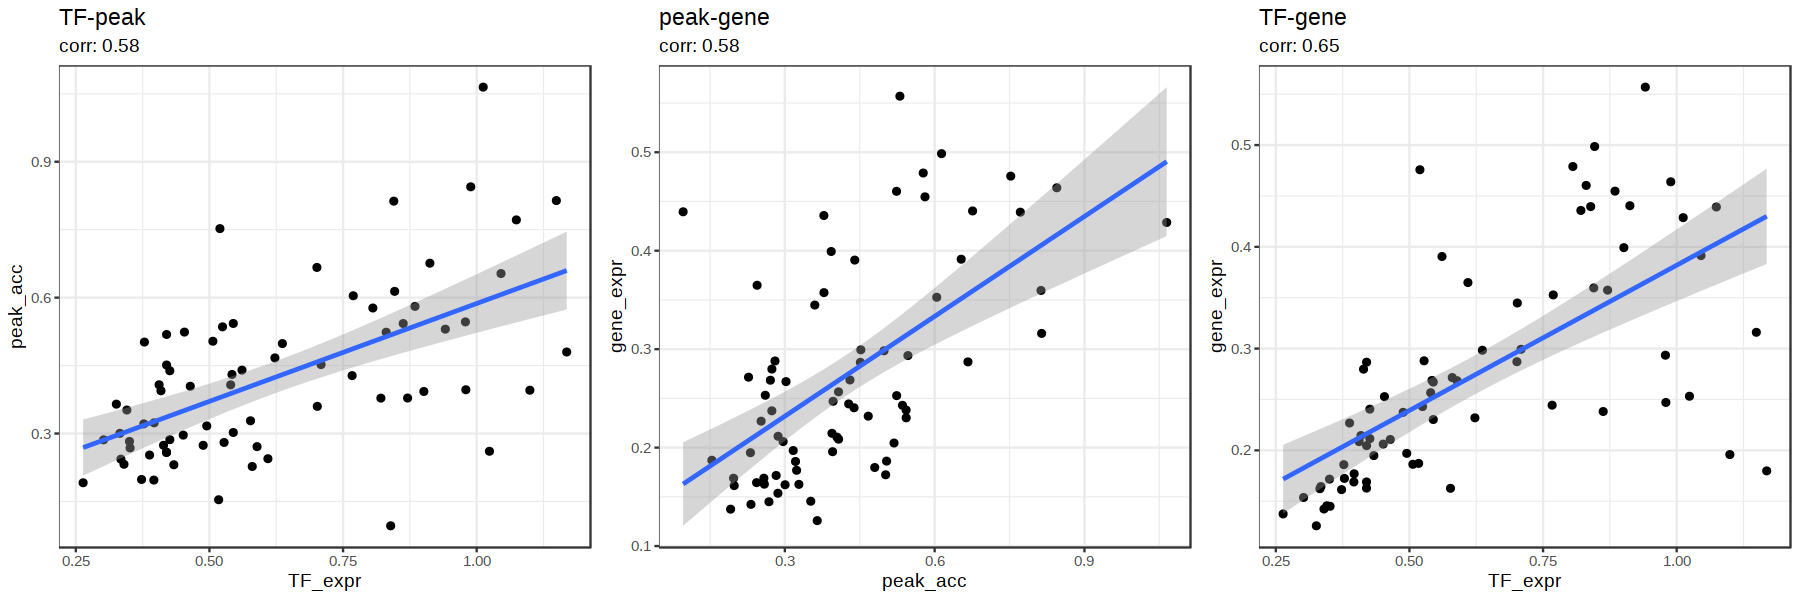

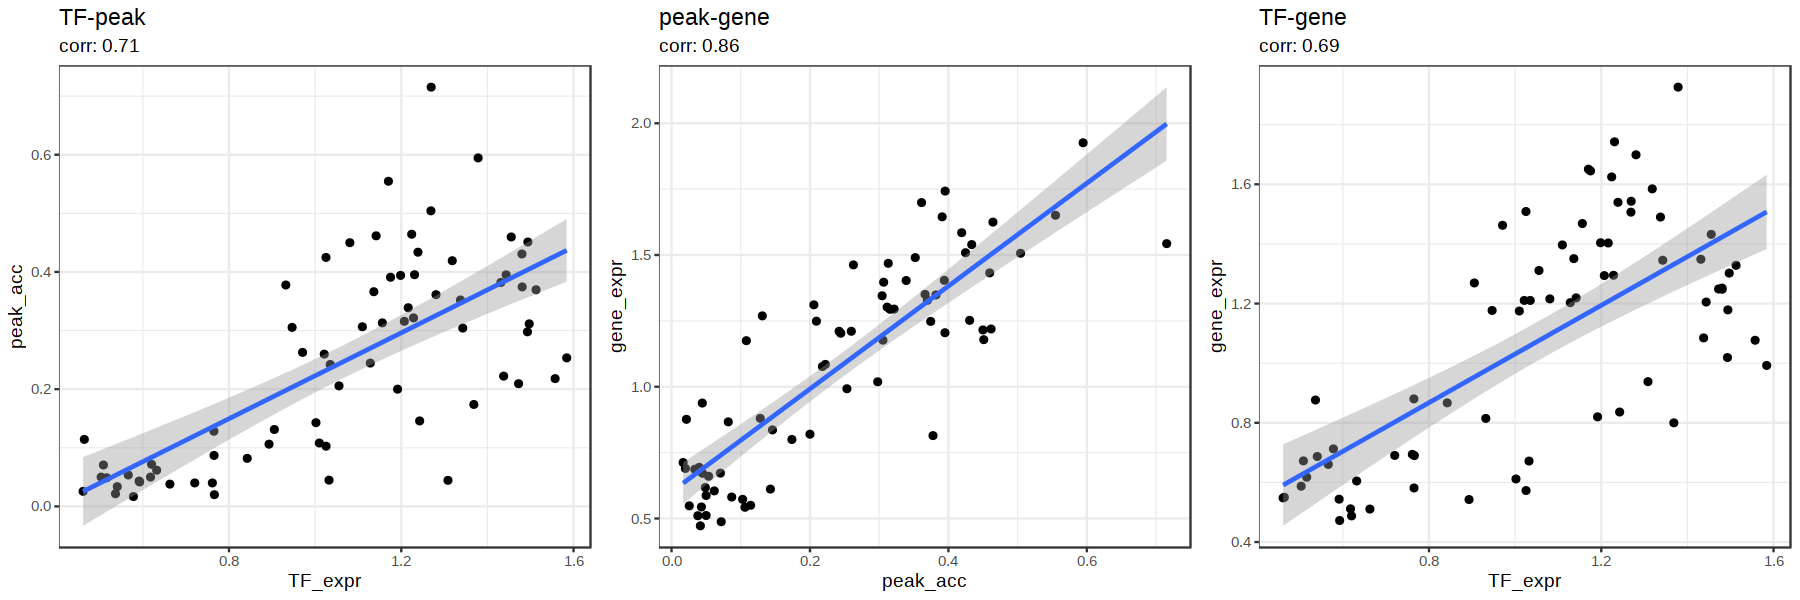

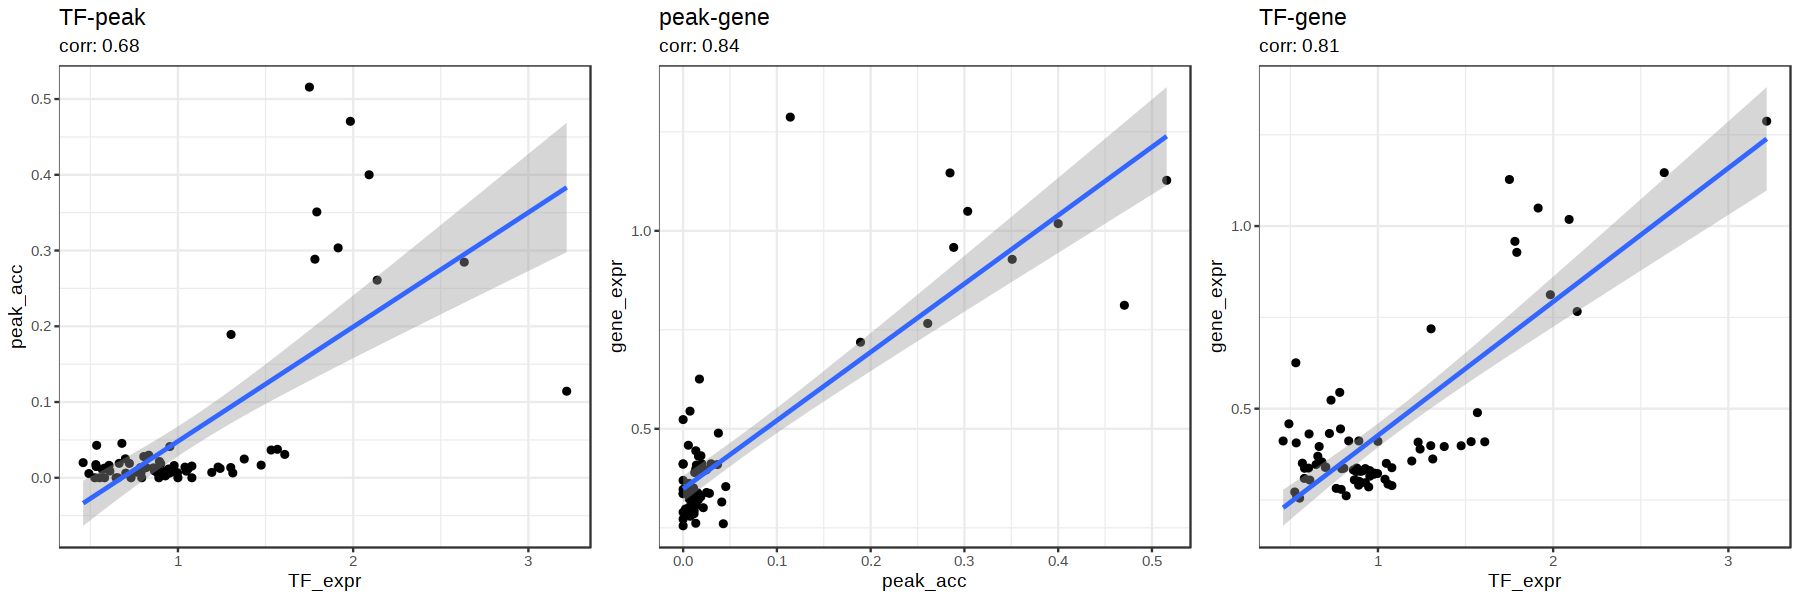

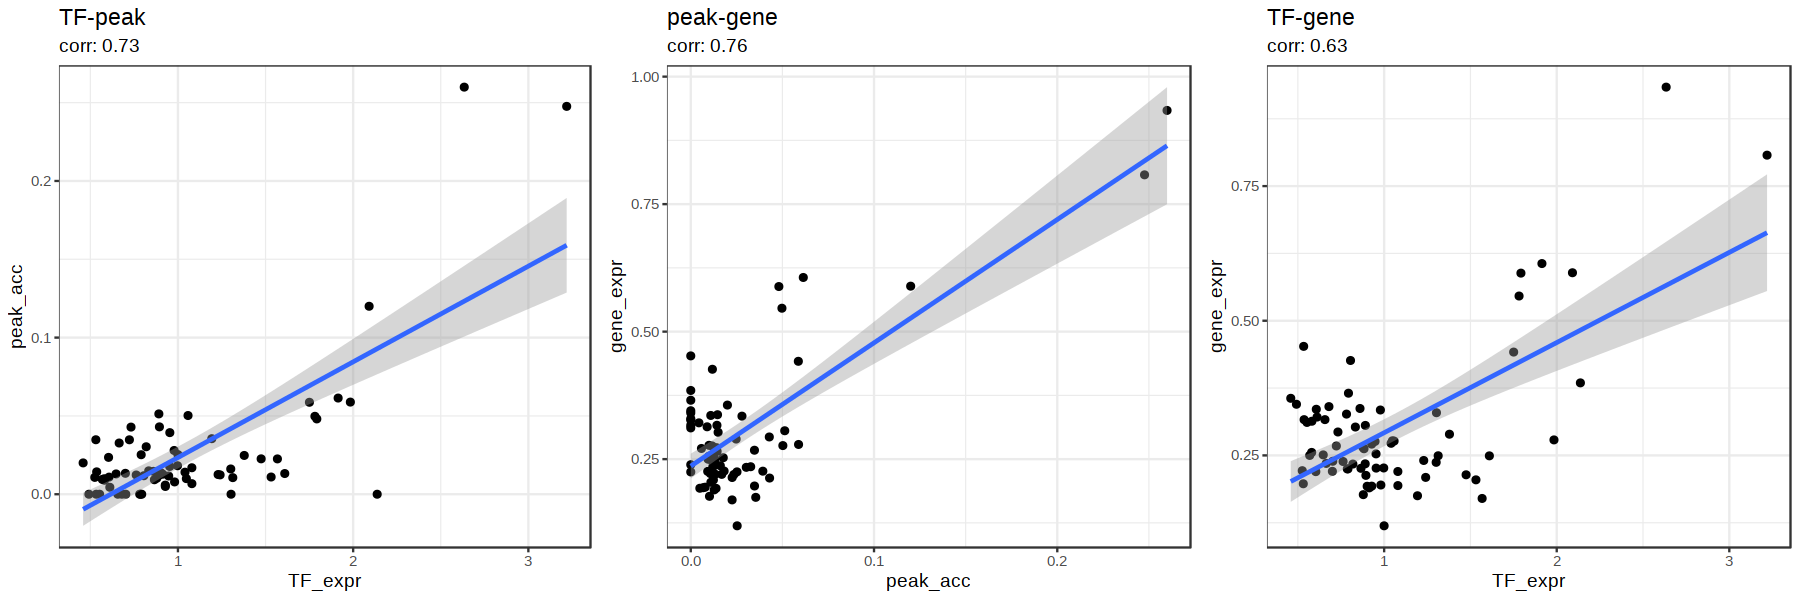

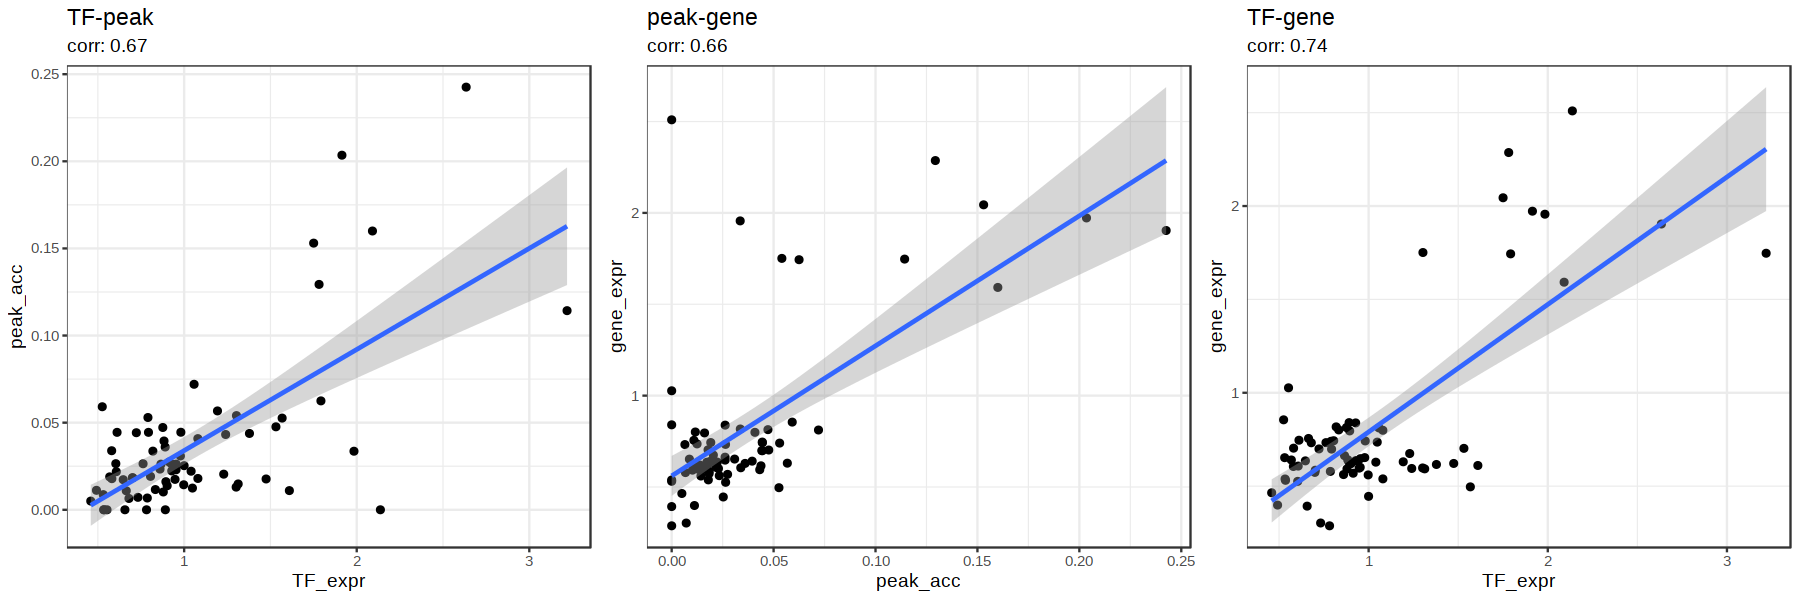

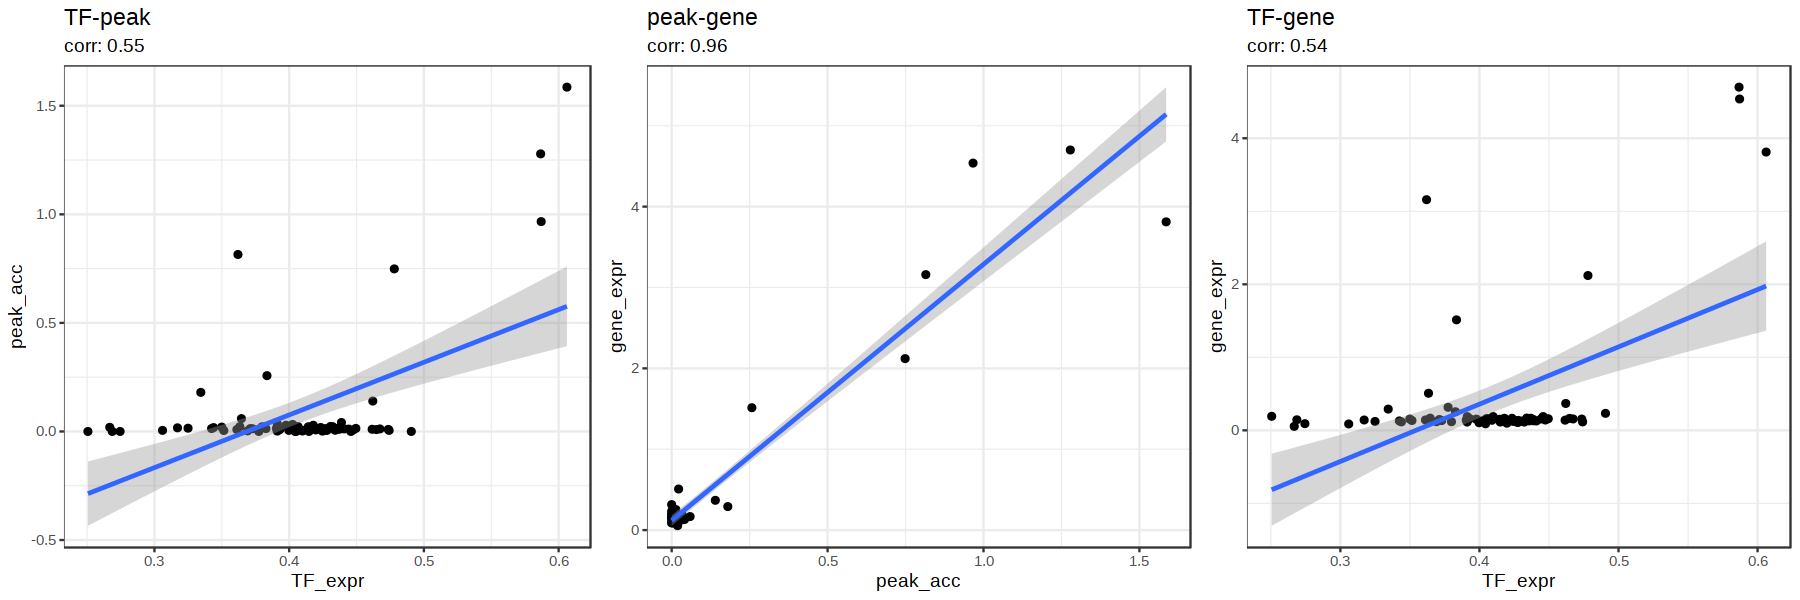

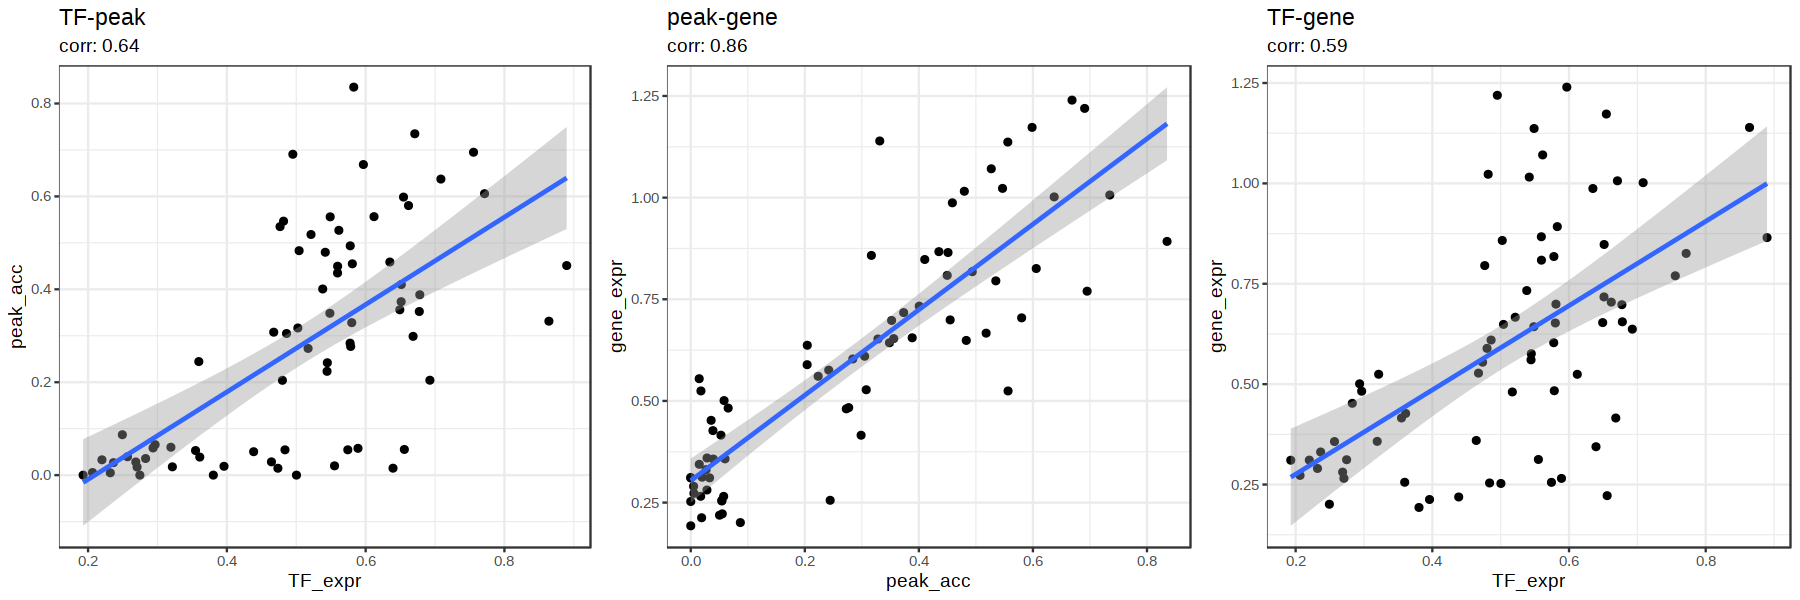

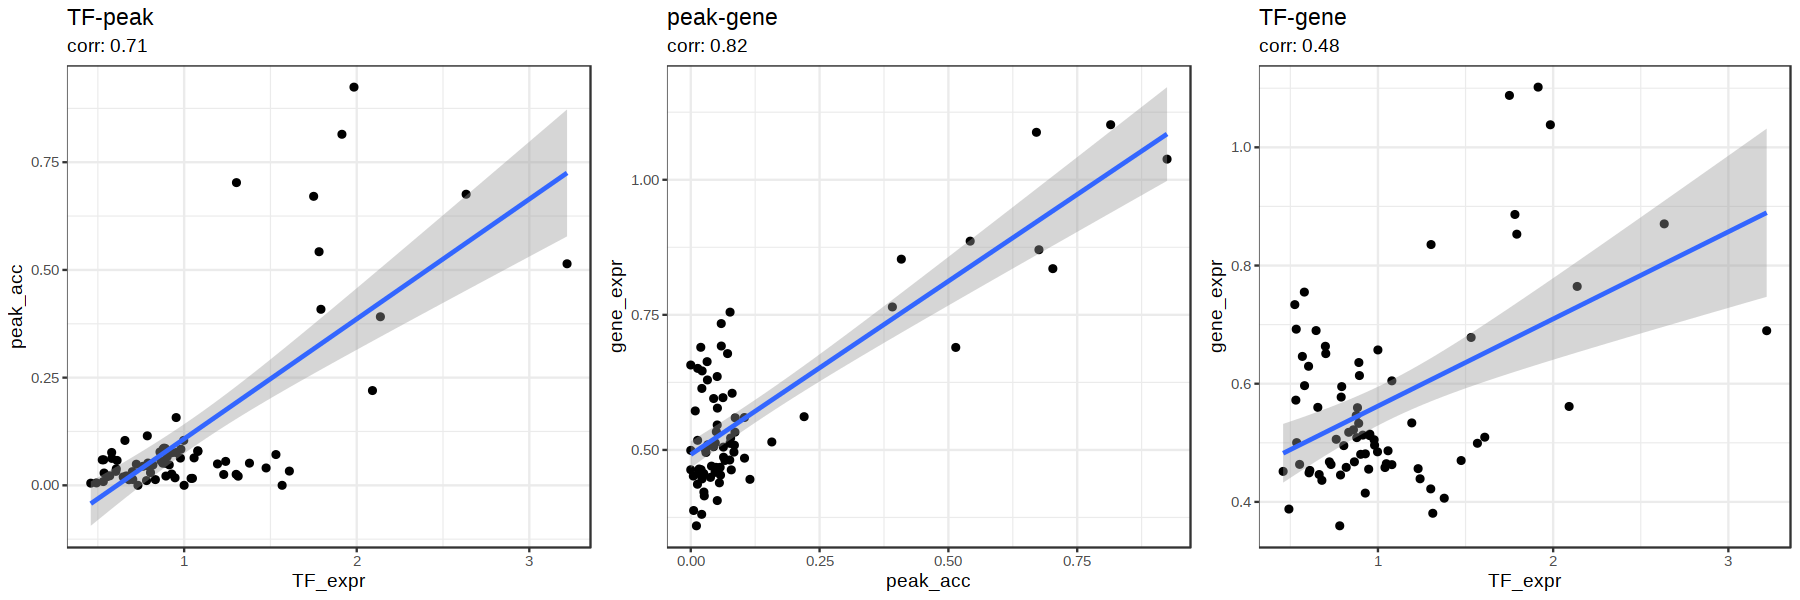

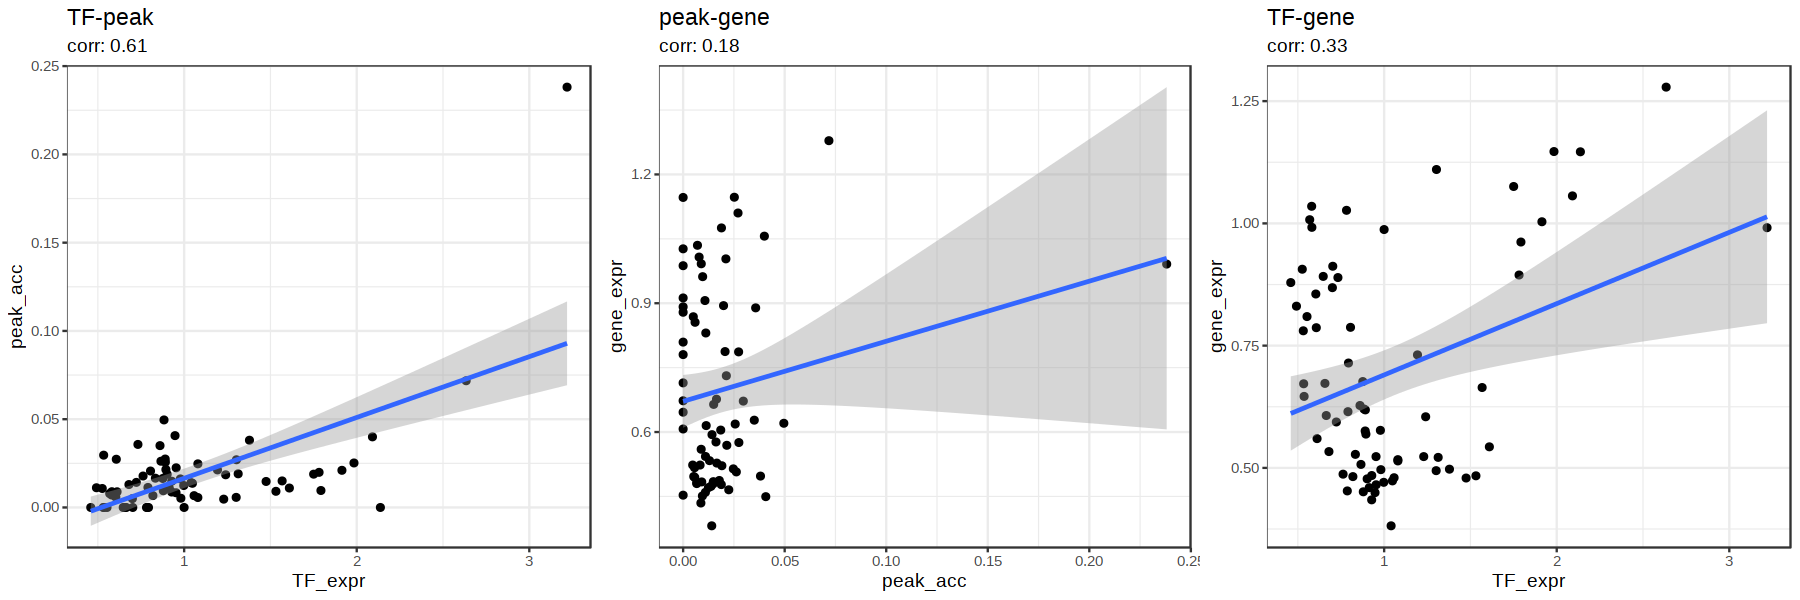

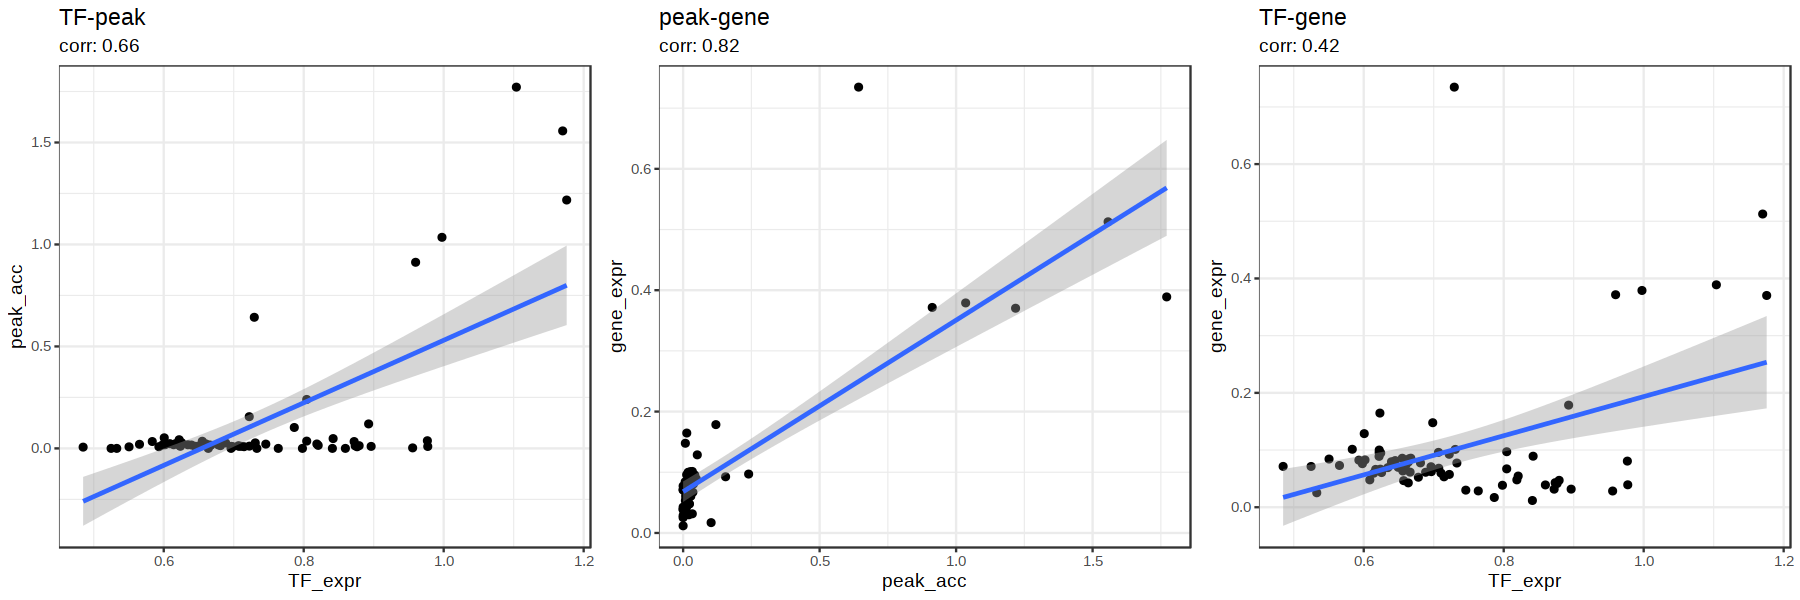

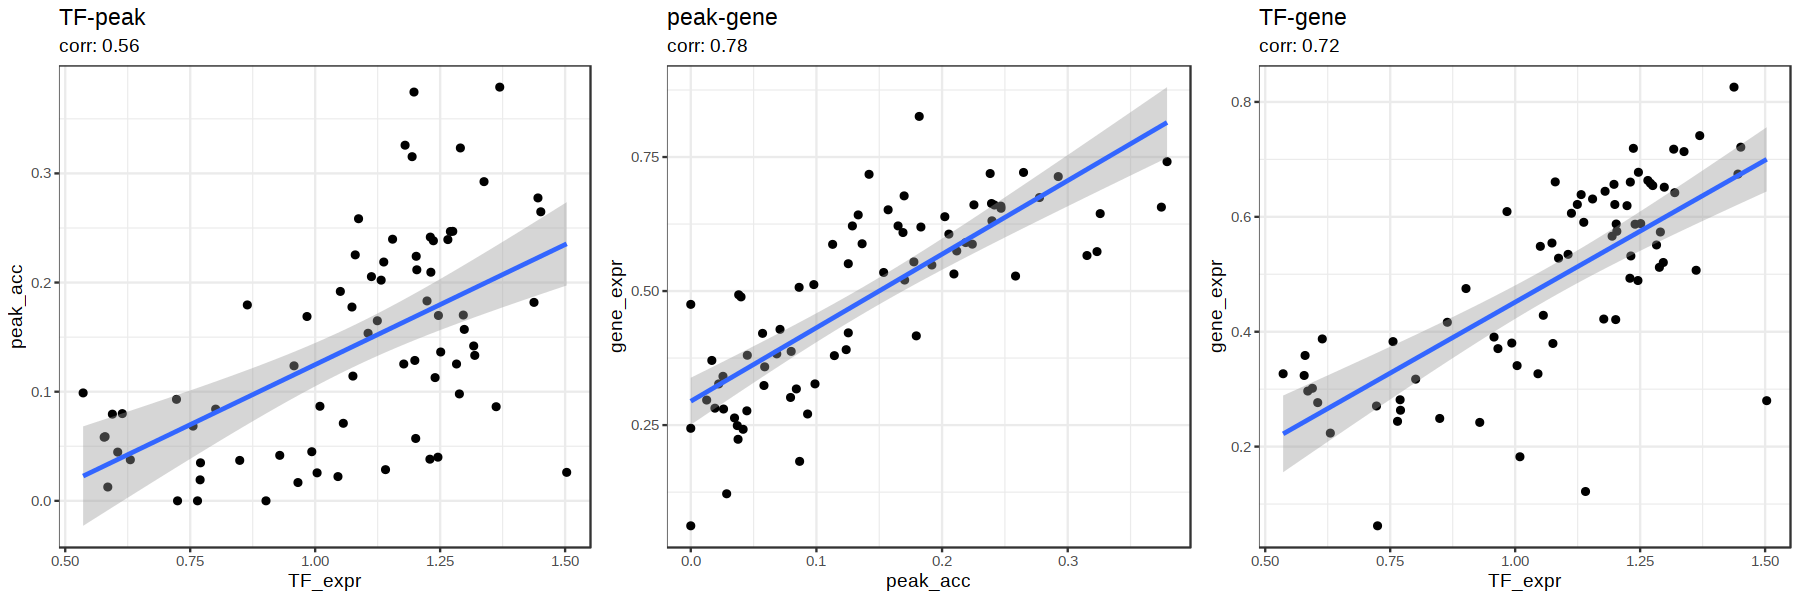

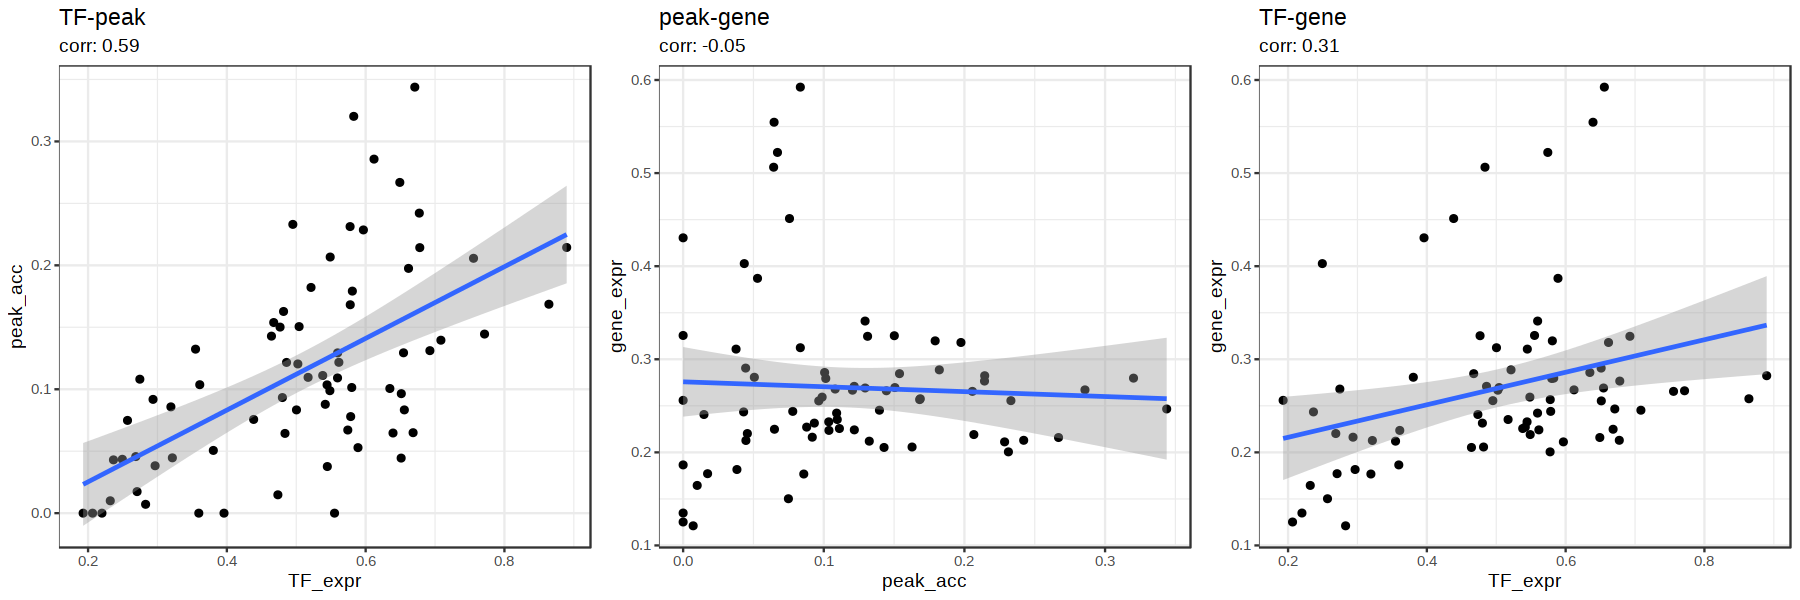

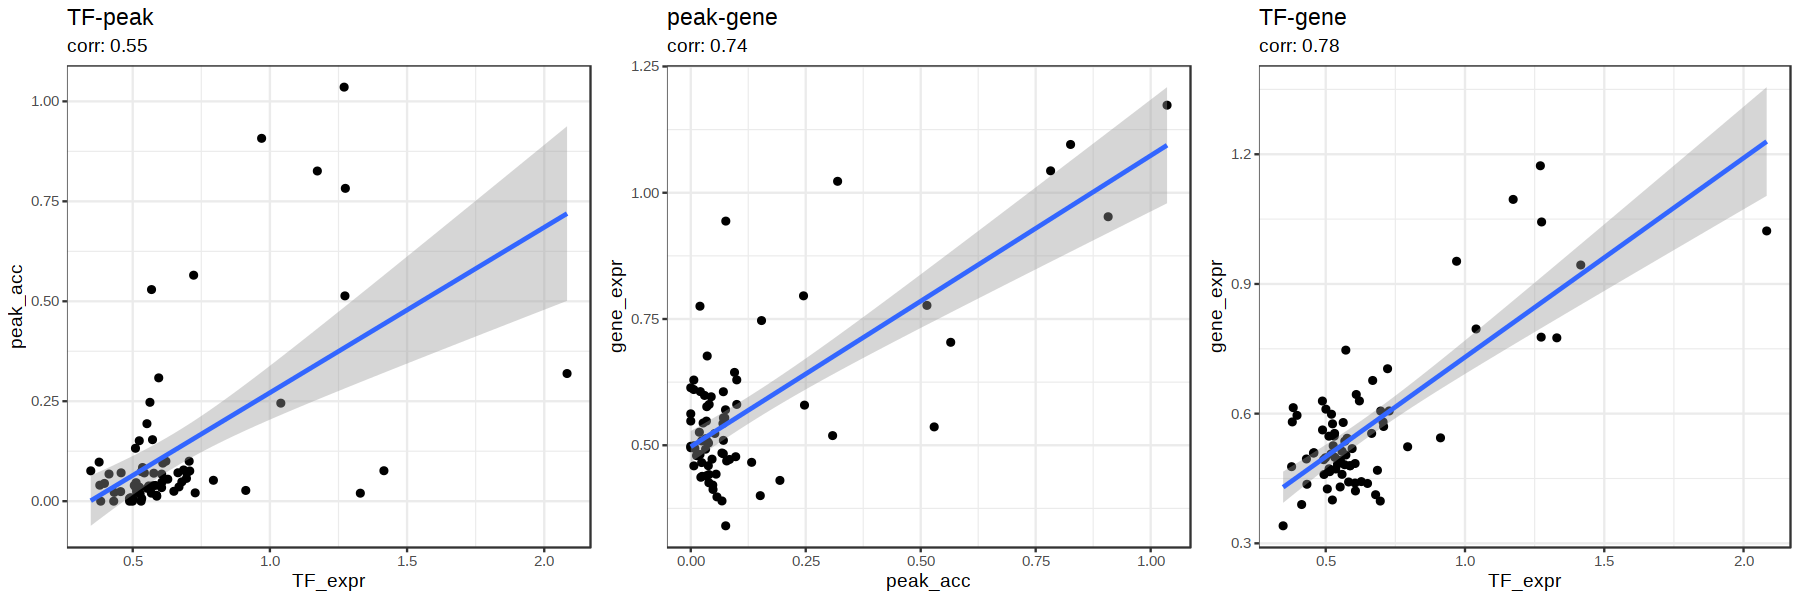

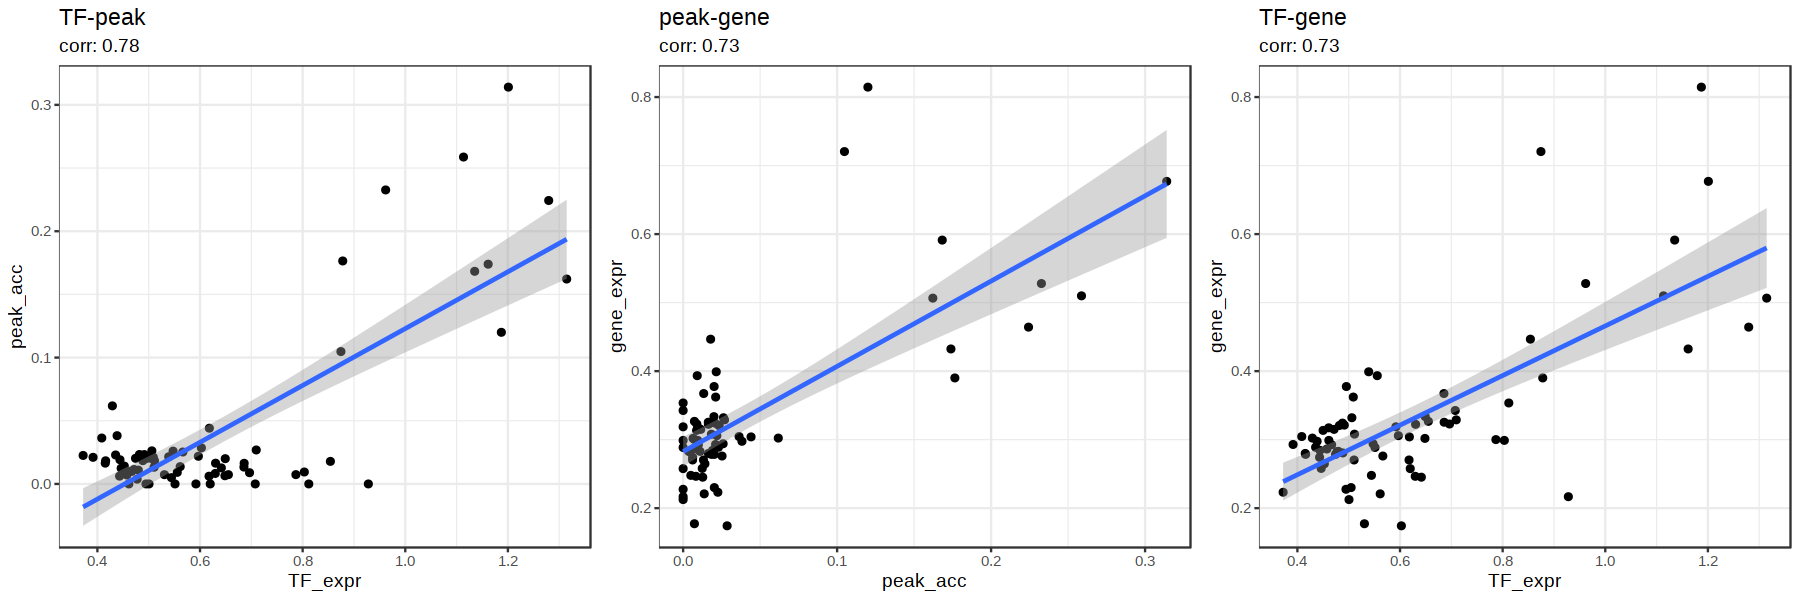

[[1]]

[[2]]

[[3]]

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]

[[12]]

[[13]]

[[14]]

[[15]]

[[16]]

[[17]]

[[18]]

[[19]]

[[20]]

[[21]]

[[22]]

[[23]]

[[24]]

[[25]]

[[26]]

[[27]]

[[28]]

[[29]]

[[30]]

[[31]]

[[32]]

[[33]]

[[34]]

[[35]]

[[36]]

[[37]]

[[38]]

[[39]]

[[40]]

[[41]]

[[42]]

[[43]]

[[44]]

[[45]]

[[46]]

[[47]]

[[48]]

[[49]]

[[50]]


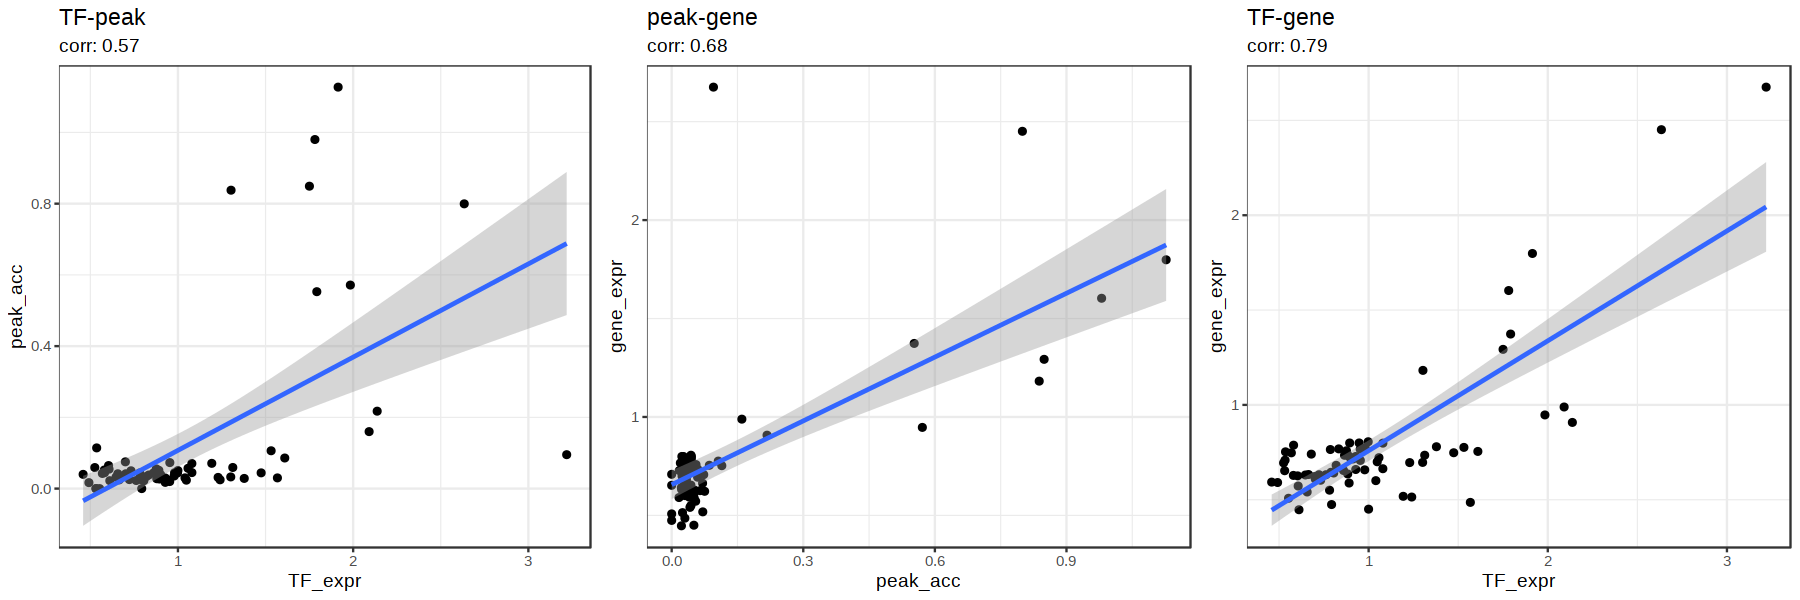

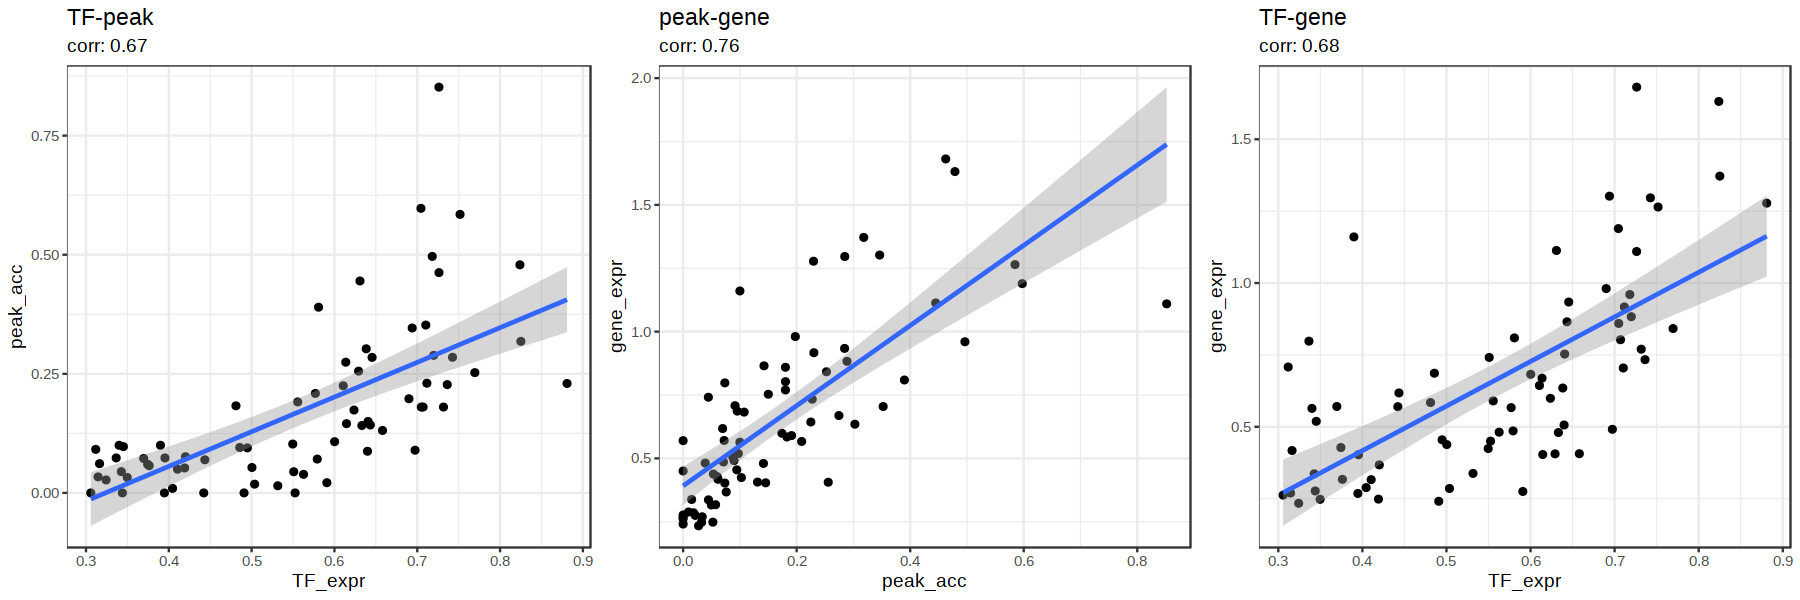

In [190]:
lapply(sample(1:1000, 50), function(row){ # 
    tmp = TF_targets_filt[row,]
    tmp = data.table(TF_expr = as.vector(genescores_pseudobulk[tmp[,tmp$TF]]@assays@data$counts),
                gene_expr = as.vector(genescores_pseudobulk[tmp[,tmp$gene]]@assays@data$counts),
                peak_acc = as.vector(peakacc_pseudobulk[tmp[,tmp$idxATAC]]@assays@data$counts))

    options(repr.plot.width=15, repr.plot.height=5)

    p1 = ggplot(tmp, aes(TF_expr, peak_acc)) + 
        geom_point() + 
        geom_smooth(method='lm') +
        ggtitle('TF-peak',
            paste0('corr: ', round(cor(tmp$TF_expr, tmp$peak_acc),2))) + 
        theme_bw()
    p2 = ggplot(tmp, aes(peak_acc, gene_expr)) + 
        geom_point() + 
        geom_smooth(method='lm') +
        ggtitle('peak-gene',
            paste0('corr: ', round(cor(tmp$peak_acc, tmp$gene_expr),2))) + 
        theme_bw()
    p3 = ggplot(tmp, aes(TF_expr, gene_expr)) + 
        geom_point() + 
        geom_smooth(method='lm') +
        ggtitle('TF-gene',
            paste0('corr: ', round(cor(tmp$TF_expr, tmp$gene_expr),2))) + 
        theme_bw()

    suppressMessages(ggarrange(p1,p2,p3, ncol=3))
})

In [186]:
#TF_targets_filt = TF_targets[TF_peak_corr>0.5 & peak_gene_corr>0.75]
GRN = TF_targets_filt[TF %in% gene & gene %in% TF] %>% 
    .[,N:=.N, by=c('TF', 'gene')] %>%
    unique(by=c('TF', 'gene'))

In [187]:
nrow(GRN)

[1] 114

In [188]:
library(igraph)

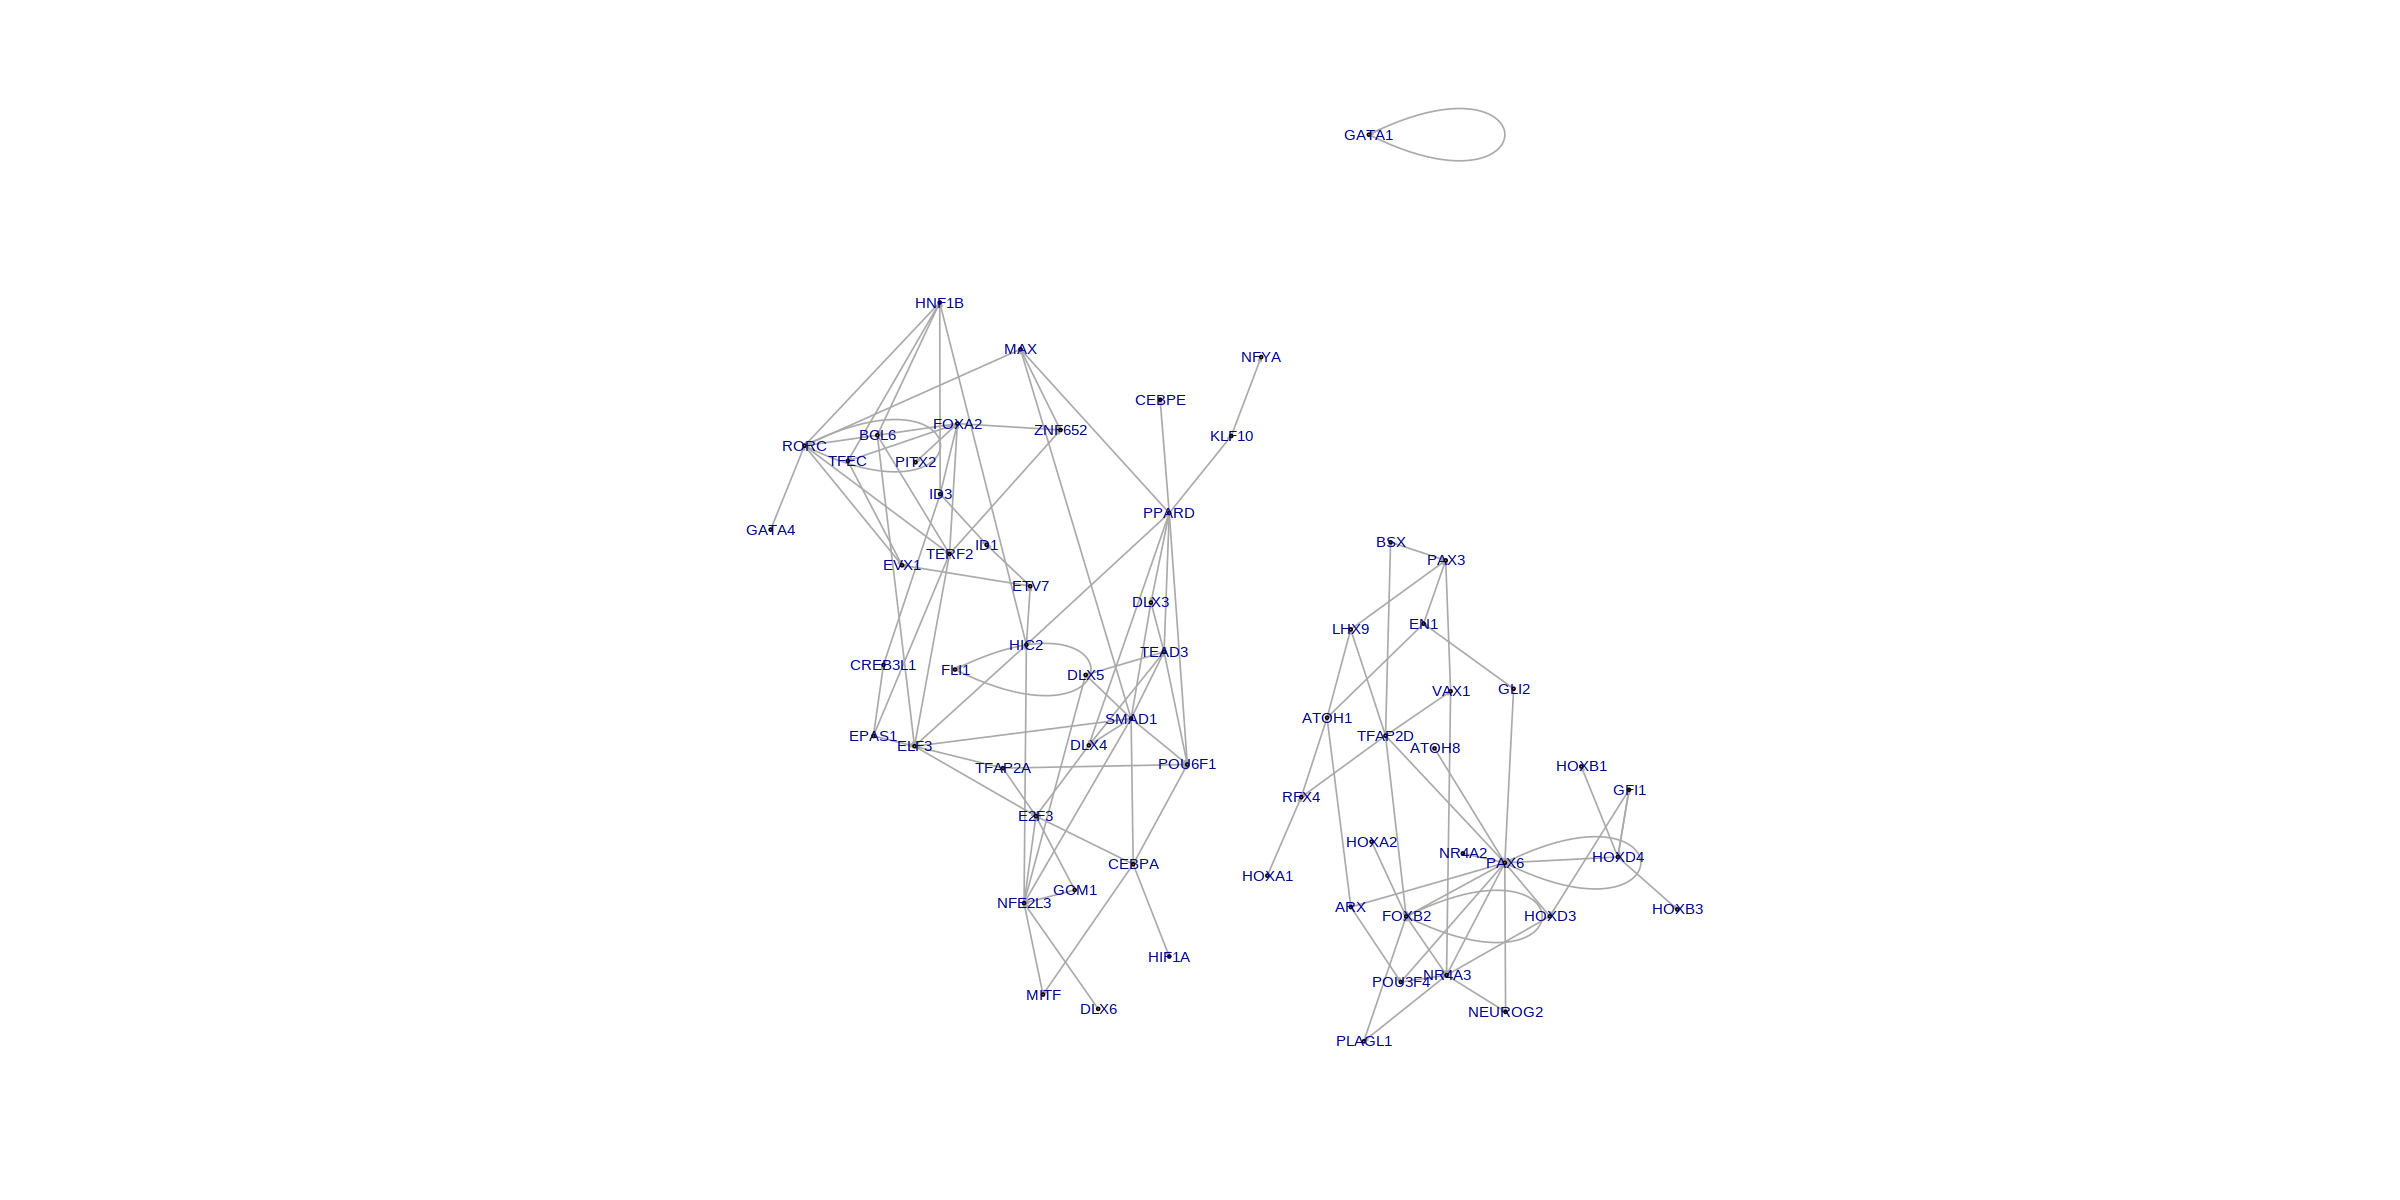

In [189]:
# Make graph of connections
g <- graph_from_data_frame(GRN[,c('TF', 'gene')], directed=TRUE)
#E(g)$weight = GRN$N
options(repr.plot.width=20, repr.plot.height=10)

plot.igraph(g, 
            vertex.size=0, 
            vertex.label.cex=0.7,
         #   edge.width=E(g)$weight/7,
            edge.arrow.size=0.1,
            layout=layout.davidson.harel)